# S4 — CMIP6 spatial relationship classification: P→Q, Surface runoff→Q, Latent heat→Q

This notebook classifies climatological P→Q, mrros→Q, and hfls→Q relationships on land cells.
Analysis is organised **by variable pair**, across Köppen-proxy zones defined in S3.

**中文说明：** 本notebook分析三个变量对：降水→径流 (P→Q)、地表径流→总径流 (mrros→Q)、潜热通量→总径流 (hfls→Q)。

## 1. Configuration / 配置

Locate S3 zone climatology output and explicitly load the case-local classifier module.

**中文说明：** 定位S3分区气候态输出，并显式加载case/caseA目录中的classifier.py；后续修改本地分类阈值即可直接作用于S4。

In [123]:
from __future__ import annotations

import importlib
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore', category=FutureWarning)


def locate_case_dir() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / 'cmip_utils.py').exists() and candidate.name == 'caseA':
            return candidate
        nested = candidate / 'case' / 'caseA'
        if (nested / 'cmip_utils.py').exists():
            return nested
    raise FileNotFoundError('Could not locate case/caseA/cmip_utils.py')


CASE_DIR = locate_case_dir()
DATA_ROOT = Path('/Volumes/mimi-T9/CMIP6')

CLASSIFIER_PATH = CASE_DIR / 'classifier.py'
if not CLASSIFIER_PATH.exists():
    raise FileNotFoundError(f'Case-local classifier not found: {CLASSIFIER_PATH}')
classifier_spec = importlib.util.spec_from_file_location(
    'caseA_classifier', CLASSIFIER_PATH
)
if classifier_spec is None or classifier_spec.loader is None:
    raise ImportError(f'Cannot create import spec for {CLASSIFIER_PATH}')
classifier_module = importlib.util.module_from_spec(classifier_spec)
classifier_spec.loader.exec_module(classifier_module)
classify_relationship = classifier_module.classify_relationship
CLASSIFIER_DEFAULTS = classifier_module.DEFAULTS

MODELS = [
    'CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5',
]
EXPERIMENTS = ['historical']
START_YEAR = 1985
END_YEAR = 2014
WRITE_OUTPUTS = True
TRIM_LOWER_QUANTILE = 0.01
TRIM_UPPER_QUANTILE = 0.99

VARIABLE_PAIRS = [
    ('P',     'Q', 'P → Q'),
    ('mrros', 'Q', 'mrros → Q'),
    ('hfls',  'Q', 'hfls → Q'),
]

DOMAINS = [
    ('all_land', 'All land', None),
    ('WW', 'Wet–warm', lambda t: t['analysis_zone'] == 'WW'),
    ('WD', 'Dry–warm', lambda t: t['analysis_zone'] == 'WD'),
    ('CW', 'Wet–cold', lambda t: t['analysis_zone'] == 'CW'),
    ('CD', 'Dry–cold', lambda t: t['analysis_zone'] == 'CD'),
    ('LI', 'Land ice', lambda t: t['analysis_zone'] == 'LI'),
]

# Colours sampled from the climate-region reference map.
ZONE_COLORS = {
    'all_land': '#6B7280',
    'non_ice_land': '#6B7280',
    'WW': '#008070',  # wet-warm, dark teal
    'WD': '#A06018',  # dry-warm, rust brown
    'CW': '#80C8C0',  # wet-cold, mint
    'CD': '#D8C078',  # dry-cold, beige
    'LI': '#3B82F6',  # land ice, blue points
}
ZONE_LEGEND = [
    ('WW', 'Wet–warm'),
    ('CW', 'Wet–cold'),
    ('CD', 'Dry–cold'),
    ('WD', 'Dry–warm'),
    ('LI', 'Land ice'),
]

# Panel background by classification family.
# Simple path = warm tints; complex path = cool tints.
CLASS_FACECOLORS = {
    # Simple: warm, different hues (apricot / sand / butter)
    'Linear': '#FFE8D2',
    'Saturation': '#F6D7C8',
    'Acceleration': '#F7E7A8',
    # Complex: cool, different hues (blue / teal / lavender / mint / slate)
    'Branch': '#D7E8F6',
    'U-shape': '#CDEEEE',
    'Cubic': '#E0D8F2',
    'Oscillation': '#D2EFDE',
    'Transition': '#D9E1F0',
    'Uncertain': '#E8E8E8',
    'No Global Relationship': '#FFFFFF',
    'No global relationship': '#FFFFFF',
    'No result': '#FFFFFF',
    'Insufficient data': '#F4F4F4',
}

# One stable colour per model on the multi-model overlay scatters.
MODEL_COLOR_CYCLE = [
    '#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00',
    '#56B4E9', '#882255', '#44AA99', '#332288', '#117733',
    '#AA4499', '#88CCEE', '#999933', '#DDCC77', '#000000',
]

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 200,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'axes.edgecolor': '#30343B',
    'axes.linewidth': 1.0, 'axes.titlesize': 14,
    'axes.titleweight': 'semibold', 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 11, 'figure.titlesize': 17,
})

print(f'Case directory: {CASE_DIR}')
print(f'Classifier path:     {CLASSIFIER_PATH}')
print(f'Classifier defaults: {CLASSIFIER_DEFAULTS}')
print(f'Domains: {[d[0] for d in DOMAINS]}')
print(f'Variable pairs: {[v[2] for v in VARIABLE_PAIRS]}')


Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Classifier path:     /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/classifier.py
Classifier defaults: {'gate1_metric': 'mic', 'mic_strong': 0.8, 'mic_intermediate': 0.2, 'dcor_strong': 0.7, 'dcor_intermediate': 0.4, 'pearson_threshold': 0.7, 'r2_power_threshold': 0.5, 'r2_autocorr_shortcut': False, 'shortcut_autocorr_max': 0.7, 'linear_b_tolerance': 0.3, 'curvature_b_threshold': 0.3, 'autocorr_threshold': 0.7, 'use_autocorr_filter': False, 'branch_n_bins': 10, 'branch_frac_threshold': 0.3, 'sizer_n_bandwidths': 4, 'sizer_n_grid': 200, 'sizer_h_min': 0.05, 'sizer_h_max': 0.3, 'sizer_interior': (0.05, 0.95), 'sizer_min_run_frac': 0.05, 'sizer_flat_frac': 0.1, 'sizer_flat_ref': 'max', 'tp_support_min': 2, 'force_complex': False}
Domains: ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']
Variable pairs: ['P → Q', 'mrros → Q', 'hfls → Q']


## 2. Load S3 zone climatology / 加载S3分区气候态

Read the zone climatology table produced by S3. Verify expected columns and zone labels.

**中文说明：** 读取S3输出的分区气候态表，验证列名和分区标签。

In [124]:
RUNS = []
SKIPPED_MODELS = []
for model in MODELS:
    for experiment in EXPERIMENTS:
        search_root = DATA_ROOT / model / experiment
        zone_name = f'zone_climatology_{START_YEAR}_{END_YEAR}.parquet'
        zone_paths = sorted(search_root.glob(f'*/*/land/zones/{zone_name}'))
        if not zone_paths:
            SKIPPED_MODELS.append(model)
            print(f'{model}: no S3 zone climatology, skip')
            continue
        for zp in zone_paths:
            zones_dir = zp.parent
            run_root = zones_dir.parent.parent
            member = run_root.parent.name
            grid = run_root.name
            RUNS.append({
                'model': model,
                'experiment': experiment,
                'member': member,
                'grid': grid,
                'zone_climatology_path': zp,
                'zones_dir': zones_dir,
                'run_root': run_root,
            })

for run in RUNS:
    t = pd.read_parquet(run['zone_climatology_path'])
    t.rename(columns={'R': 'Q'}, inplace=True)
    run['clim'] = t
    required = {'P', 'ET', 'Q', 'analysis_zone', 'surface_class', 'core_zone_cell', 'grid_id', 'land_area'}
    missing = required - set(t.columns)
    if missing:
        raise KeyError(f'Missing columns in S3 output: {sorted(missing)}')
    print(f"{run['model']} {run['member']} {run['grid']}: {len(t)} rows")
    print(f"  analysis_zone: {sorted(t['analysis_zone'].unique())}")
    print(f"  surface_class: {sorted(t['surface_class'].unique())}")

print(f'\nLoaded {len(RUNS)} runs, skipped {len(SKIPPED_MODELS)}: {SKIPPED_MODELS}')
if not RUNS:
    raise FileNotFoundError('No S3 zone climatology found for any requested model')


CESM2 r1i1p1f1 gn: 21013 rows
  analysis_zone: ['CD', 'CW', 'EF', 'KG_unclassified', 'LI', 'WD', 'WW']
  surface_class: ['land_ice', 'non_ice_land']
CNRM-CM6-1 r1i1p1f2 gr: 13639 rows
  analysis_zone: ['CD', 'CW', 'KG_unclassified', 'LI', 'WD', 'WW']
  surface_class: ['land_ice', 'non_ice_land']
CanESM5 r1i1p1f1 gn: 3464 rows
  analysis_zone: ['CD', 'CW', 'KG_unclassified', 'LI', 'WD', 'WW']
  surface_class: ['land_ice', 'non_ice_land']
GFDL-CM4 r1i1p1f1 gr1: 22514 rows
  analysis_zone: ['CD', 'CW', 'EF', 'KG_unclassified', 'LI', 'WD', 'WW']
  surface_class: ['land_ice', 'non_ice_land']
CMCC-CM2-SR5 r1i1p1f1 gn: 20675 rows
  analysis_zone: ['CD', 'CW', 'EF', 'KG_unclassified', 'LI', 'WD', 'WW']
  surface_class: ['land_ice', 'non_ice_land']

Loaded 5 runs, skipped 0: []


## 3. Run classifier on P→Q and mrros→Q / 对 P→Q 和 mrros→Q 运行分类器

Classify every domain × sample for both raw and trimmed cells on the two selected pairs.

**中文说明：** 对两个选定变量对在所有分域×样本组合上运行分类器（raw和trimmed）。

In [125]:
import os
import time as _time
from concurrent.futures import ThreadPoolExecutor, as_completed

import dcor as _dcor

# Reload classifier.py from disk so edits apply without restarting the kernel.
classifier_spec = importlib.util.spec_from_file_location(
    'caseA_classifier', CLASSIFIER_PATH
)
classifier_module = importlib.util.module_from_spec(classifier_spec)
classifier_spec.loader.exec_module(classifier_module)
classify_relationship = classifier_module.classify_relationship
CLASSIFIER_DEFAULTS = classifier_module.DEFAULTS
print(f'Reloaded classifier: {CLASSIFIER_PATH}')
print(f'Defaults: {CLASSIFIER_DEFAULTS}')


def prepare_pair_versions(x, y, groups=None):
    """Return finite raw values and a paired 1–99% trimmed sensitivity sample."""
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    finite = np.isfinite(x_arr) & np.isfinite(y_arr)
    x_raw = x_arr[finite]
    y_raw = y_arr[finite]
    groups_raw = None if groups is None else np.asarray(groups)[finite]
    if len(x_raw) == 0:
        bounds = (np.nan, np.nan, np.nan, np.nan)
        keep = np.zeros(0, dtype=bool)
    else:
        x_lo, x_hi = np.quantile(
            x_raw, [TRIM_LOWER_QUANTILE, TRIM_UPPER_QUANTILE]
        )
        y_lo, y_hi = np.quantile(
            y_raw, [TRIM_LOWER_QUANTILE, TRIM_UPPER_QUANTILE]
        )
        bounds = (float(x_lo), float(x_hi), float(y_lo), float(y_hi))
        keep = (
            (x_raw >= x_lo) & (x_raw <= x_hi)
            & (y_raw >= y_lo) & (y_raw <= y_hi)
        )
    return {
        'raw': (x_raw, y_raw),
        'trimmed': (x_raw[keep], y_raw[keep]),
        'raw_groups': groups_raw,
        'trimmed_groups': None if groups_raw is None else groups_raw[keep],
        'trim_keep': keep,
        'bounds': bounds,
    }


def run_classification(x_clean, y_clean, x_name, y_name, domain_name,
                       sample_name, outlier_version, raw_n_cells, bounds):
    """Run one raw or trimmed classifier and retain trimming diagnostics."""
    x_clean = np.asarray(x_clean, dtype=float)
    y_clean = np.asarray(y_clean, dtype=float)
    n = len(x_clean)
    x_lo, x_hi, y_lo, y_hi = bounds
    n_removed = int(raw_n_cells - n)
    metadata = {
        'domain': domain_name,
        'sample': sample_name,
        'outlier_version': outlier_version,
        'x_var': x_name,
        'y_var': y_name,
        'pair': f'{x_name} → {y_name}',
        'n_cells': n,
        'raw_n_cells': int(raw_n_cells),
        'n_removed': n_removed,
        'removed_fraction': (n_removed / raw_n_cells if raw_n_cells else np.nan),
        'x_trim_lower': x_lo,
        'x_trim_upper': x_hi,
        'y_trim_lower': y_lo,
        'y_trim_upper': y_hi,
    }
    pearson_r_descriptive = np.nan
    dcor_value = np.nan
    if n >= 2 and np.ptp(x_clean) > 0 and np.ptp(y_clean) > 0:
        pearson_r_descriptive = float(np.corrcoef(x_clean, y_clean)[0, 1])
        dcor_value = float(_dcor.distance_correlation(x_clean, y_clean))
    if n < 10:
        return {
            **metadata,
            'pearson_r_descriptive': pearson_r_descriptive,
            'dcor': dcor_value,
            'group': 'Insufficient data',
            'mic': np.nan,
            'has_global_relationship': 'N/A',
            'simple_or_complex': 'N/A',
            'branch_structure': 'N/A',
            'tp_number': None,
        }
    result = classify_relationship(x_clean, y_clean)
    return {
        **metadata,
        **result,
        'pearson_r_descriptive': pearson_r_descriptive,
        'dcor': dcor_value,
    }


def run_pair_versions(frame, x_name, y_name, domain_name, sample_name):
    prepared = prepare_pair_versions(frame[x_name], frame[y_name])
    raw_n = len(prepared['raw'][0])
    results = []
    for version in ['raw', 'trimmed']:
        x_values, y_values = prepared[version]
        results.append(run_classification(
            x_values, y_values, x_name, y_name, domain_name, sample_name,
            version, raw_n, prepared['bounds'],
        ))
    return results


# ── Pre-build all jobs as numpy arrays ──────────────────────
# Trimming is computed GLOBALLY (all_land) per model×pair, then applied
# to each domain subset, so all zones share the same outlier thresholds.
JOBS = []
for run in RUNS:
    t = run['clim']
    run_meta = {
        'model': run['model'],
        'experiment': run['experiment'],
        'member': run['member'],
        'grid': run['grid'],
    }

    # Pre-compute global trim bounds per variable pair
    global_bounds = {}
    for x_var, y_var, pair_label in VARIABLE_PAIRS:
        if x_var not in t.columns or y_var not in t.columns:
            continue
        x_all = np.asarray(t[x_var], dtype=float)
        y_all = np.asarray(t[y_var], dtype=float)
        finite = np.isfinite(x_all) & np.isfinite(y_all)
        xf, yf = x_all[finite], y_all[finite]
        if len(xf) == 0:
            global_bounds[(x_var, y_var)] = (np.nan, np.nan, np.nan, np.nan)
        else:
            x_lo, x_hi = np.quantile(xf, [TRIM_LOWER_QUANTILE, TRIM_UPPER_QUANTILE])
            y_lo, y_hi = np.quantile(yf, [TRIM_LOWER_QUANTILE, TRIM_UPPER_QUANTILE])
            global_bounds[(x_var, y_var)] = (float(x_lo), float(x_hi), float(y_lo), float(y_hi))

    for domain_key, domain_label, domain_filter in DOMAINS:
        subset = t.loc[domain_filter(t)] if domain_filter is not None else t
        sample_frames = [('all', subset)]
        if domain_key in ('WW', 'WD', 'CW', 'CD'):
            sample_frames.append(('core', subset.loc[subset['core_zone_cell']]))
        for sample_name, sample_frame in sample_frames:
            for x_var, y_var, pair_label in VARIABLE_PAIRS:
                if (x_var, y_var) not in global_bounds:
                    continue
                x_arr = np.asarray(sample_frame[x_var], dtype=float)
                y_arr = np.asarray(sample_frame[y_var], dtype=float)
                finite = np.isfinite(x_arr) & np.isfinite(y_arr)
                x_raw = x_arr[finite]
                y_raw = y_arr[finite]
                raw_n = len(x_raw)
                bounds = global_bounds[(x_var, y_var)]
                x_lo, x_hi, y_lo, y_hi = bounds
                keep = (
                    (x_raw >= x_lo) & (x_raw <= x_hi)
                    & (y_raw >= y_lo) & (y_raw <= y_hi)
                )
                for version in ['raw', 'trimmed']:
                    if version == 'trimmed':
                        xv, yv = x_raw[keep], y_raw[keep]
                    else:
                        xv, yv = x_raw, y_raw
                    JOBS.append((
                        xv.copy(), yv.copy(),
                        x_var, y_var, domain_key, sample_name,
                        version, raw_n, bounds, run_meta,
                    ))

def _worker(job):
    x, y, x_name, y_name, domain, sample, version, raw_n, bounds, meta = job
    res = run_classification(x, y, x_name, y_name, domain, sample, version, raw_n, bounds)
    res.update(meta)
    return res

# ── Run in parallel ─────────────────────────────────────────
N_WORKERS = max(1, (os.cpu_count() or 4) - 1)
print(f'Running {len(JOBS)} classifications on {N_WORKERS} threads ...')
_t0 = _time.perf_counter()

ALL_RESULTS = []
_done = 0
with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = [pool.submit(_worker, job) for job in JOBS]
    for fut in as_completed(futures):
        ALL_RESULTS.append(fut.result())
        _done += 1
        if _done % 50 == 0 or _done == len(JOBS):
            print(f'  {_done}/{len(JOBS)} done')

_elapsed = _time.perf_counter() - _t0
print(f'Finished in {_elapsed:.1f}s')

ALL_RESULTS.sort(key=lambda r: (
    r['model'], r['domain'], r['pair'], r['sample'], r['outlier_version']
))

RESULTS_DF = pd.DataFrame(ALL_RESULTS)
print(f'\nTotal classifications: {len(RESULTS_DF)}')
for version in ['raw', 'trimmed']:
    n = int((RESULTS_DF['outlier_version'] == version).sum())
    print(f'  {version}: {n} cases')

Reloaded classifier: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/classifier.py
Defaults: {'gate1_metric': 'mic', 'mic_strong': 0.8, 'mic_intermediate': 0.2, 'dcor_strong': 0.7, 'dcor_intermediate': 0.4, 'pearson_threshold': 0.7, 'r2_power_threshold': 0.5, 'r2_autocorr_shortcut': False, 'shortcut_autocorr_max': 0.7, 'linear_b_tolerance': 0.3, 'curvature_b_threshold': 0.3, 'autocorr_threshold': 0.7, 'use_autocorr_filter': False, 'branch_n_bins': 10, 'branch_frac_threshold': 0.3, 'sizer_n_bandwidths': 4, 'sizer_n_grid': 200, 'sizer_h_min': 0.05, 'sizer_h_max': 0.3, 'sizer_interior': (0.05, 0.95), 'sizer_min_run_frac': 0.05, 'sizer_flat_frac': 0.1, 'sizer_flat_ref': 'max', 'tp_support_min': 2, 'force_complex': False}
Running 300 classifications on 9 threads ...


## 6. Pair analysis — RAW / 按变量对（raw）

For P→Q and mrros→Q: one summary table then one multi-model figure. Each panel is a domain; every model with data appears.

**中文说明：** 对 P→Q 和 mrros→Q 分别给出汇总表和多模型叠加散点图。

In [111]:
from statsmodels.nonparametric.smoothers_lowess import lowess as _lowess


def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#30343B')
        spine.set_linewidth(1.0)
    ax.tick_params(
        direction='out', length=4.0, width=0.9,
        color='#30343B', labelsize=11,
    )
    ax.grid(True, color='#D3D3D3', linewidth=0.6, alpha=0.7, zorder=0)


UNIT_LABELS = {
    'P': 'Precipitation, P (mm yr⁻¹)',
    'ET': 'Evapotranspiration, ET (mm yr⁻¹)',
    'Q': 'Total runoff, Q (mm yr⁻¹)',
    'hfls': 'Latent heat flux (W m⁻²)',
    'hfss': 'Sensible heat flux (W m⁻²)',
    'tran': 'Transpiration (mm yr⁻¹)',
    'evspsblsoi': 'Soil evaporation (mm yr⁻¹)',
    'mrros': 'Surface runoff (mm yr⁻¹)',
    'mrso': 'Total soil moisture (kg m⁻²)',
    'mrsos': 'Topsoil moisture (kg m⁻²)',
    'lai': 'Leaf area index (m² m⁻²)',
    'tas': 'Near-surface temperature (K)',
    'prsn': 'Snowfall (mm yr⁻¹)',
    'rlds': 'Downward LW radiation (W m⁻²)',
    'rlus': 'Upward LW radiation (W m⁻²)',
    'rsds': 'Downward SW radiation (W m⁻²)',
    'rsus': 'Upward SW radiation (W m⁻²)',
}
PAIR_SLUGS = {label: f'{x}_{y}' for x, y, label in VARIABLE_PAIRS}


def draw_lowess_fit(ax, x_values, y_values, frac=0.3, it=3):
    x_arr = np.asarray(x_values, dtype=float)
    y_arr = np.asarray(y_values, dtype=float)
    finite = np.isfinite(x_arr) & np.isfinite(y_arr)
    xf, yf = x_arr[finite], y_arr[finite]
    if len(xf) < 10:
        return False
    result = _lowess(yf, xf, frac=frac, it=it, return_sorted=True)
    ax.plot(
        result[:, 0], result[:, 1], color='#B12A68', linewidth=1.2,
        linestyle='-', alpha=0.4, zorder=5,
    )
    return True


def draw_density_kde(ax, x_values, y_values, cmap='Reds', n_levels=12, n_grid=100):
    """KDE contour density plot with scatter overlay."""
    from scipy.stats import gaussian_kde
    x_arr = np.asarray(x_values, dtype=float)
    y_arr = np.asarray(y_values, dtype=float)
    finite = np.isfinite(x_arr) & np.isfinite(y_arr)
    xf, yf = x_arr[finite], y_arr[finite]
    if len(xf) < 20:
        ax.scatter(xf, yf, s=5, c='k', alpha=0.4, rasterized=True)
        return
    xy = np.vstack([xf, yf])
    try:
        kde = gaussian_kde(xy)
    except np.linalg.LinAlgError:
        ax.scatter(xf, yf, s=5, c='k', alpha=0.4, rasterized=True)
        return
    xi = np.linspace(xf.min(), xf.max(), n_grid)
    yi = np.linspace(yf.min(), yf.max(), n_grid)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    Zi_log = np.log10(np.maximum(Zi, 1e-20))
    ax.contourf(Xi, Yi, Zi_log, levels=n_levels, cmap=cmap, alpha=0.85, zorder=1)
    ax.scatter(xf, yf, s=2, c='k', alpha=0.15, edgecolors='none', rasterized=True, zorder=2)


def draw_density_hexbin(ax, x_values, y_values, cmap='Reds', gridsize=20):
    """Hexbin density plot."""
    from matplotlib.colors import LogNorm
    x_arr = np.asarray(x_values, dtype=float)
    y_arr = np.asarray(y_values, dtype=float)
    finite = np.isfinite(x_arr) & np.isfinite(y_arr)
    xf, yf = x_arr[finite], y_arr[finite]
    if len(xf) < 20:
        ax.scatter(xf, yf, s=5, c='k', alpha=0.4, rasterized=True)
        return
    ax.hexbin(xf, yf, gridsize=gridsize, cmap=cmap, mincnt=1, norm=LogNorm(), zorder=1)


# Full names for figure titles (abbreviation → readable name)
PAIR_FULL_NAMES = {}
for _x, _y, _label in VARIABLE_PAIRS:
    _x_name = UNIT_LABELS.get(_x, _x).split('(')[0].strip().rstrip(',')
    _y_name = UNIT_LABELS.get(_y, _y).split('(')[0].strip().rstrip(',')
    PAIR_FULL_NAMES[_label] = f'{_x_name} → {_y_name}'
SUMMARY_COLUMNS = [
    'model', 'domain', 'n_cells', 'n_removed', 'removed_fraction',
    'mic', 'pearson_r_descriptive', 'group', 'path_trace',
]
S4_OUTPUT_DIR = CASE_DIR / 'output' / 'S4'
S4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = S4_OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def assign_model_colors(model_names):
    ordered = list(dict.fromkeys(model_names))
    return {
        name: MODEL_COLOR_CYCLE[i % len(MODEL_COLOR_CYCLE)]
        for i, name in enumerate(ordered)
    }


MODEL_COLORS = assign_model_colors([run['model'] for run in RUNS])
print('Model colours:')
for name, color in MODEL_COLORS.items():
    print(f'  {name}: {color}')


def padded_limits(values, pad_fraction=0.04):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (-1.0, 1.0)
    lower, upper = float(values.min()), float(values.max())
    span = upper - lower
    if not np.isfinite(span) or span == 0:
        span = max(abs(lower), 1.0)
    pad = pad_fraction * span
    return lower - pad, upper + pad


def lookup_result_row(model, domain_key, x_var, y_var, version):
    rows = RESULTS_DF.loc[
        (RESULTS_DF['model'] == model)
        & (RESULTS_DF['domain'] == domain_key)
        & (RESULTS_DF['sample'] == 'all')
        & (RESULTS_DF['x_var'] == x_var)
        & (RESULTS_DF['y_var'] == y_var)
        & (RESULTS_DF['outlier_version'] == version)
    ]
    if len(rows) != 1:
        return None
    return rows.iloc[0]


def collect_overlay_series(x_var, y_var, domain_key, domain_filter, version):
    """Points for every model that has finite cells in this domain."""
    series = []
    for run in RUNS:
        table = run['clim']
        subset = table if domain_filter is None else table.loc[domain_filter(table)]
        if subset.empty:
            continue
        prepared = prepare_pair_versions(subset[x_var], subset[y_var])
        x_raw, y_raw = prepared['raw']
        if len(x_raw) == 0:
            continue
        x_vals, y_vals = prepared[version]
        keep = prepared['trim_keep']
        series.append({
            'model': run['model'],
            'x': x_vals,
            'y': y_vals,
            'x_raw': x_raw,
            'y_raw': y_raw,
            'trim_keep': keep,
            'xlim_src': x_raw,
            'ylim_src': y_raw,
            'result': lookup_result_row(
                run['model'], domain_key, x_var, y_var, version
            ),
        })
    return series


def pair_summary_table(pair_label, version):
    table = RESULTS_DF.loc[
        (RESULTS_DF['pair'] == pair_label)
        & (RESULTS_DF['outlier_version'] == version)
        & (RESULTS_DF['sample'] == 'all'),
        [c for c in SUMMARY_COLUMNS if c in RESULTS_DF.columns],
    ].copy()
    table = table.sort_values(['domain', 'model'])
    display_table = table.astype(object).where(pd.notna(table), '-').replace('N/A', '-')
    print(
        f'\n=== {version.upper()} · {pair_label} · all models '
        f'({len(display_table)} rows) ==='
    )
    display(
        display_table.style.set_properties(
            **{'text-align': 'left', 'white-space': 'nowrap', 'font-size': '12px'}
        )
    )
    out = S4_OUTPUT_DIR / f'S4_summary_{PAIR_SLUGS[pair_label]}_{version}.csv'
    if WRITE_OUTPUTS:
        table.to_csv(out, index=False)
        print(f'saved {out}')
    return table


def draw_pair_overlay_figure(x_var, y_var, pair_label, version):
    n_domains = len(DOMAINS)
    n_cols = 4
    n_rows = int(np.ceil(n_domains / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    legend_handles = []
    seen_models = []

    for idx, (domain_key, domain_label, domain_filter) in enumerate(DOMAINS):
        ax = axes[idx]
        series = collect_overlay_series(
            x_var, y_var, domain_key, domain_filter, version
        )
        x_pool, y_pool = [], []
        for item in series:
            x_pool.append(item['xlim_src'])
            y_pool.append(item['ylim_src'])
            color = MODEL_COLORS[item['model']]
            if version == 'trimmed':
                dropped = ~np.asarray(item['trim_keep'], dtype=bool)
                if dropped.any():
                    ax.scatter(
                        item['x_raw'][dropped], item['y_raw'][dropped],
                        marker='x', s=18, c=color, alpha=0.80,
                        linewidths=0.7, zorder=1, rasterized=True,
                    )
            if len(item['x']) > 0:
                ax.scatter(
                    item['x'], item['y'],
                    s=10, c=color, alpha=0.3,
                    edgecolors='none', rasterized=True, zorder=2,
                    label=item['model'],
                )
                draw_lowess_fit(ax, item['x'], item['y'])
            if item['model'] not in seen_models:
                seen_models.append(item['model'])
                legend_handles.append(
                    Line2D(
                        [0], [0], marker='o', color='none',
                        markerfacecolor=color, markeredgecolor='none',
                        markersize=10, alpha=0.6,
                        label=item['model'],
                    )
                )
        if series:
            ax.set_xlim(padded_limits(np.concatenate(x_pool)))
            ax.set_ylim(padded_limits(np.concatenate(y_pool)))
        else:
            ax.text(
                0.5, 0.5, 'No models with data',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=13, color='#6B7280',
            )
        ax.set_title(f'{domain_label}  ({domain_key})', fontsize=14, pad=8)
        ax.set_xlabel(UNIT_LABELS[x_var], fontsize=13)
        ax.set_ylabel(UNIT_LABELS[y_var], fontsize=13)
        style_axes(ax)
        panel_letter = chr(ord('a') + idx)
        ax.text(
            0.02, 0.98, panel_letter,
            transform=ax.transAxes, va='top', ha='left',
            fontsize=13, fontweight='bold', color='#222222',
        )

    for ax in axes[n_domains:]:
        ax.set_visible(False)

    fig.suptitle(
        f'{version.upper()}  ·  {PAIR_FULL_NAMES.get(pair_label, pair_label)}  ·  all models with data',
        fontsize=18, fontweight='semibold', y=1.05,
    )
    if legend_handles:
        fig.legend(
            handles=legend_handles,
            loc='lower center',
            ncol=min(5, len(legend_handles)),
            bbox_to_anchor=(0.5, -0.14),
            frameon=True,
            fancybox=True,
            framealpha=0.5,
            edgecolor='none',
            fontsize=12,
            markerscale=1.3,
            title='Model (colour)',
            title_fontsize=13,
        )
        if version == 'trimmed':
            fig.legend(
                handles=[
                    Line2D(
                        [0], [0], marker='x', color='#444444',
                        linestyle='none', markersize=8,
                        label='Removed (outside 1st–99th percentile on x or y)',
                    )
                ],
                loc='lower center',
                bbox_to_anchor=(0.5, -0.20),
                frameon=True,
                fancybox=True,
                framealpha=0.5,
                edgecolor='none',
                fontsize=11,
            )
    if WRITE_OUTPUTS:
        path = FIGURE_DIR / f'S4_overlay_{PAIR_SLUGS[pair_label]}_{version}.png'
        fig.savefig(path, dpi=180, bbox_inches='tight')
        print(f'saved {path}')
    plt.show()
    plt.close(fig)


# print('RAW pair analysis')
# print('=' * 72)
# for x_var, y_var, pair_label in VARIABLE_PAIRS:
#     print('\n' + '#' * 72)
#     print(f'RAW · {pair_label}')
#     print('#' * 72)
#     pair_summary_table(pair_label, 'raw')
#     draw_pair_overlay_figure(x_var, y_var, pair_label, 'raw')



SHAPE_FACECOLORS = {
    'Linear':       '#E8F5E9',
    'Saturating':   '#FFF3E0',
    'Accelerating': '#E3F2FD',
    'S-shape':      '#F3E5F5',
    'Flat/Weak':    '#F5F5F5',
    'U-shape':      '#FFF9C4',
    'Arch-shape':   '#FFE0B2',
    'Complex':      '#FFEBEE',
    'Insufficient data': '#FFFFFF',
}


def extract_lowess_shape(x_data, y_data, frac=0.3, it=3):
    """Fit LOWESS and extract shape features from the smoothed curve."""
    from scipy.signal import find_peaks

    x_arr = np.asarray(x_data, dtype=float)
    y_arr = np.asarray(y_data, dtype=float)
    finite = np.isfinite(x_arr) & np.isfinite(y_arr)
    xf, yf = x_arr[finite], y_arr[finite]
    if len(xf) < 20:
        return None

    result = _lowess(yf, xf, frac=frac, it=it, return_sorted=True)
    xs, ys = result[:, 0], result[:, 1]

    y_range = ys.max() - ys.min()
    x_range = xs.max() - xs.min()
    if x_range == 0 or y_range == 0:
        return None

    # Power-law fit on LOWESS curve: y = a * x^b
    # Fit in log-log space, evaluate R² in original space
    power_b = np.nan
    power_r2 = np.nan
    abs_b_minus_1 = np.nan
    pos_mask = (xs > 0) & (ys > 0)
    if pos_mask.sum() >= 10:
        log_x = np.log(xs[pos_mask])
        log_y = np.log(ys[pos_mask])
        coef = np.polyfit(log_x, log_y, 1)
        power_b = coef[0]
        abs_b_minus_1 = abs(power_b - 1.0)
        # R² in original space: power law prediction vs LOWESS curve
        y_pred = np.exp(np.polyval(coef, log_x))
        y_actual = ys[pos_mask]
        ss_res = np.sum((y_actual - y_pred) ** 2)
        ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
        power_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 1.0

    # First derivative
    dx = np.diff(xs)
    dy = np.diff(ys)
    mask = dx > 0
    dx, dy = dx[mask], dy[mask]
    if len(dx) < 5:
        return None
    slope = dy / dx

    # Second derivative
    x_mid = 0.5 * (xs[:-1][mask] + xs[1:][mask])
    dx2 = np.diff(x_mid)
    dslope = np.diff(slope)
    mask2 = dx2 > 0
    curvature = dslope[mask2] / dx2[mask2] if mask2.any() else np.array([])

    norm_slope = slope * (x_range / y_range)

    frac_positive = (slope > 0).mean()
    frac_negative = (slope < 0).mean()
    mean_norm_slope = norm_slope.mean()
    slope_std = norm_slope.std()

    n_edge = max(3, int(0.2 * len(slope)))
    slope_start = float(np.median(slope[:n_edge]))
    slope_end = float(np.median(slope[-n_edge:]))

    if len(curvature) > 0:
        frac_concave = (curvature > 0).mean()
        mean_curvature = float(np.mean(curvature * (x_range**2 / y_range)))
        half = len(curvature) // 2
        curv_first_half = curvature[:half].mean() if half > 0 else 0
        curv_second_half = curvature[half:].mean()
    else:
        frac_concave = np.nan
        mean_curvature = np.nan
        curv_first_half = 0
        curv_second_half = 0

    net_change = (ys[-1] - ys[0]) / y_range if y_range > 0 else 0

    # Turning points via find_peaks with prominence
    amplitude = np.ptp(ys)
    n_peaks, n_troughs = 0, 0
    if amplitude > 1e-10:
        prom = max(0.10 * amplitude, 1e-10)
        min_dist = max(5, int(0.08 * len(ys)))
        peaks, _ = find_peaks(ys, prominence=prom, distance=min_dist)
        troughs, _ = find_peaks(-ys, prominence=prom, distance=min_dist)
        n_peaks = len(peaks)
        n_troughs = len(troughs)

    return {
        'frac_positive_slope': frac_positive,
        'frac_negative_slope': frac_negative,
        'mean_norm_slope': mean_norm_slope,
        'slope_std': slope_std,
        'slope_start': slope_start,
        'slope_end': slope_end,
        'frac_concave': frac_concave,
        'mean_curvature': mean_curvature,
        'net_change': net_change,
        'curv_first_half': curv_first_half,
        'curv_second_half': curv_second_half,
        'power_b': power_b,
        'power_r2': power_r2,
        'abs_b_minus_1': abs_b_minus_1,
        'n_peaks': n_peaks,
        'n_troughs': n_troughs,
    }


def classify_lowess_shape(feat, flat_thresh=0.15):
    """Assign a shape label based on extracted LOWESS features."""
    if feat is None:
        return 'Insufficient data'

    net = feat['net_change']
    frac_pos = feat['frac_positive_slope']
    frac_neg = feat['frac_negative_slope']
    frac_concave = feat['frac_concave']
    power_b = feat['power_b']
    power_r2 = feat['power_r2']
    abs_b_1 = feat['abs_b_minus_1']
    n_peaks = feat['n_peaks']
    n_troughs = feat['n_troughs']
    n_tp = n_peaks + n_troughs

    # 1. Flat / Weak
    if abs(net) < flat_thresh:
        if n_peaks == 1 and n_troughs == 0:
            return 'Arch-shape'
        if n_troughs == 1 and n_peaks == 0:
            return 'U-shape'
        return 'Flat/Weak'

    # 2. Power-law fit first — if it fits well, use b to classify
    has_power = np.isfinite(power_b) and np.isfinite(power_r2)
    is_monotone_inc = frac_pos >= 0.80
    is_monotone_dec = frac_neg >= 0.80
    is_monotone = is_monotone_inc or is_monotone_dec

    if has_power and power_r2 >= 0.50 and is_monotone:
        if abs_b_1 < 0.15:
            return 'Linear'
        if power_b > 1.15:
            return 'Accelerating'
        if power_b < 0.85:
            # Cross-check: if curvature says concave-up, trust curvature
            if is_monotone_inc and frac_concave > 0.55:
                return 'Accelerating'
            return 'Saturating'

    # 3. Power-law fit poor — check turning points
    if n_tp >= 3:
        return 'Complex'
    if n_peaks == 1 and n_troughs == 0:
        return 'Arch-shape'
    if n_troughs == 1 and n_peaks == 0:
        return 'U-shape'
    if n_tp == 2:
        return 'S-shape'

    # 4. Monotone but power-law R² low — use curvature only if R² is moderate
    if is_monotone:
        if not has_power or power_r2 < 0.50:
            return 'Complex'
        if is_monotone_inc and frac_concave < 0.40:
            return 'Saturating'
        if is_monotone_dec and frac_concave > 0.60:
            return 'Saturating'
        if is_monotone_inc and frac_concave > 0.60:
            return 'Accelerating'
        if is_monotone_dec and frac_concave < 0.40:
            return 'Accelerating'
        return 'Linear'

    # 5. Non-monotone without clear turning points
    c1 = feat['curv_first_half']
    c2 = feat['curv_second_half']
    if c1 * c2 < 0:
        return 'S-shape'

    return 'Complex' 


Model colours:
  CESM2: #0072B2
  CNRM-CM6-1: #D55E00
  CanESM5: #009E73
  GFDL-CM4: #CC79A7
  CMCC-CM2-SR5: #E69F00


## 6b. Pair analysis — TRIMMED / 按变量对（trimmed）

Same tables and multi-model overlays as the raw section, for the two selected pairs.

**中文说明：** 与 raw 部分相同的表和图，仅针对两个变量对的 trimmed 版本。

In [112]:
# print('TRIMMED pair analysis')
# print('=' * 72)
# for x_var, y_var, pair_label in VARIABLE_PAIRS:
#     print('\n' + '#' * 72)
#     print(f'TRIMMED · {pair_label}')
#     print('#' * 72)
#     pair_summary_table(pair_label, 'trimmed')
#     draw_pair_overlay_figure(x_var, y_var, pair_label, 'trimmed')


## 6c. Per-model scatter plots — RAW / 单模型散点（raw）

Two variable-pair rows (P→Q, mrros→Q) × domain columns per model.

**中文说明：** 每个模型两行（P→Q, mrros→Q）× 分域列的散点图。

In [113]:
N_EQUAL_COUNT_BINS = CLASSIFIER_DEFAULTS['branch_n_bins']


def equal_count_bin_medians(x, y, n_bins=N_EQUAL_COUNT_BINS):
    frame = pd.DataFrame({'x': x, 'y': y}).replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if len(frame) < 2 or frame['x'].nunique() < 2:
        return pd.DataFrame(columns=['x', 'y', 'n'])
    q = min(int(n_bins), int(frame['x'].nunique()))
    frame['bin'] = pd.qcut(frame['x'], q=q, duplicates='drop')
    curve = frame.groupby('bin', observed=True).agg(
        x=('x', 'median'), y=('y', 'median'), n=('y', 'size')
    ).reset_index(drop=True)
    return curve.sort_values('x')




def metric_text(row, column):
    value = row.get(column, np.nan)
    return f'{value:.3f}' if pd.notna(value) else '—'


def display_class(group):
    return {
        'No Global Relationship': 'No global relationship',
    }.get(str(group), str(group))


def classification_facecolor(group):
    if group is None:
        return '#FFFFFF'
    try:
        if isinstance(group, float) and np.isnan(group):
            return '#FFFFFF'
    except TypeError:
        pass
    key = str(group)
    if key in CLASS_FACECOLORS:
        return CLASS_FACECOLORS[key]
    return CLASS_FACECOLORS.get(display_class(key), '#FFFFFF')


def format_panel_annotation(result_row, version, raw_row=None):
    """Return (class_name, detail_text). Class is drawn bold; no 'Final class' prefix."""
    if result_row is None:
        return 'No result', ''
    final_class = display_class(result_row['group'])
    if final_class in {'', 'nan', 'None'}:
        final_class = 'No result'
    details = (
        f"MIC={metric_text(result_row, 'mic')}  "
        f"dcor={metric_text(result_row, 'dcor')}  "
        f"r={metric_text(result_row, 'pearson_r_descriptive')}\n"
        f"n={int(result_row['n_cells'])}"
    )
    if pd.notna(result_row.get('power_r2', np.nan)):
        details += (
            f"  R²={float(result_row['power_r2']):.3f}"
            f"  |b−1|={float(result_row.get('abs_b_minus_1', np.nan)):.3f}"
        )
    if version == 'trimmed':
        details += (
            f"\nrem={int(result_row['n_removed'])} "
            f"({100 * float(result_row['removed_fraction']):.1f}%)"
        )
        if raw_row is not None and raw_row['group'] != result_row['group']:
            details += (
                f"  {display_class(raw_row['group'])} → {final_class}"
            )
    return final_class, details


def draw_class_annotation(ax, class_name, details, *, fontsize=9.2, y=0.96):
    """Bold class name, then metrics — one box, no overlapping text."""
    from matplotlib.offsetbox import AnnotationBbox, TextArea, VPacker

    title = TextArea(
        class_name,
        textprops={
            'fontsize': fontsize + 0.8,
            'fontweight': 'bold',
            'color': '#111111',
            'family': 'DejaVu Sans',
        },
    )
    children = [title]
    if details:
        children.append(
            TextArea(
                details,
                textprops={
                    'fontsize': fontsize,
                    'fontweight': 'normal',
                    'color': '#202020',
                    'family': 'DejaVu Sans',
                },
            )
        )
    pack = VPacker(children=children, align='left', pad=0, sep=3)
    box = AnnotationBbox(
        pack,
        (0.03, y),
        xycoords='axes fraction',
        box_alignment=(0.0, 1.0),
        frameon=True,
        pad=0.30,
        bboxprops={
            'boxstyle': 'round,pad=0.35',
            'facecolor': 'white',
            'edgecolor': '#C9C9C9',
            'alpha': 0.92,
        },
        zorder=8,
    )
    ax.add_artist(box)


def scatter_points(ax, x_data, y_data, domain_key, groups,
                   dropped=None, dropped_groups=None):
    if dropped is not None:
        xd, yd = dropped
        if len(xd) > 0:
            if domain_key == 'non_ice_land' and dropped_groups is not None:
                dcolors = [ZONE_COLORS.get(str(z), '#B0B0B0') for z in dropped_groups]
                ax.scatter(
                    xd, yd, marker='x', s=16, c=dcolors, alpha=0.85,
                    linewidths=0.7, zorder=1, rasterized=True,
                )
            else:
                ax.scatter(
                    xd, yd, marker='x', s=16,
                    color=ZONE_COLORS.get(domain_key, '#555555'),
                    alpha=0.85, linewidths=0.7, zorder=1, rasterized=True,
                )
    if len(x_data) == 0:
        if dropped is None or len(dropped[0]) == 0:
            ax.text(
                0.5, 0.5, 'Unavailable', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='#6B7280',
            )
        return
    if domain_key == 'non_ice_land' and groups is not None:
        colors = [ZONE_COLORS.get(str(z), '#B0B0B0') for z in groups]
        ax.scatter(
            x_data, y_data, s=7, c=colors, alpha=0.55,
            edgecolors='none', rasterized=True, zorder=2,
        )
        return
    color = ZONE_COLORS.get(domain_key, '#555555')
    size = 8 if domain_key == 'LI' else 7
    ax.scatter(
        x_data, y_data, s=size, color=color, alpha=0.55,
        edgecolors='none', rasterized=True, zorder=2,
    )


def build_panel_payloads(run):
    t = run['clim']
    payloads = {}
    for x_var, y_var, pair_label in VARIABLE_PAIRS:
        for domain_key, domain_label, domain_filter in DOMAINS:
            subset = t.loc[domain_filter(t)] if domain_filter is not None else t
            prepared = prepare_pair_versions(
                subset[x_var], subset[y_var],
                groups=subset['analysis_zone'] if 'analysis_zone' in subset else None,
            )
            x_raw, y_raw = prepared['raw']
            result_rows = RESULTS_DF.loc[
                (RESULTS_DF['model'] == run['model'])
                & (RESULTS_DF['experiment'] == run['experiment'])
                & (RESULTS_DF['member'] == run['member'])
                & (RESULTS_DF['grid'] == run['grid'])
                & (RESULTS_DF['domain'] == domain_key)
                & (RESULTS_DF['sample'] == 'all')
                & (RESULTS_DF['x_var'] == x_var)
                & (RESULTS_DF['y_var'] == y_var)
            ]
            payloads[(pair_label, domain_key)] = {
                'x_var': x_var,
                'y_var': y_var,
                'pair_label': pair_label,
                'domain_key': domain_key,
                'domain_label': domain_label,
                'prepared': prepared,
                'result_rows': result_rows,
                'xlim': padded_limits(x_raw),
                'ylim': padded_limits(y_raw),
            }
    return payloads


def draw_relationship_figure(run, version, panel_payloads):
    n_rows = len(VARIABLE_PAIRS)
    n_cols = len(DOMAINS)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.9 * n_cols, 4.15 * n_rows),
        constrained_layout=True, squeeze=False,
    )

    for row_i, (x_var, y_var, pair_label) in enumerate(VARIABLE_PAIRS):
        for col_i, (domain_key, domain_label, _) in enumerate(DOMAINS):
            ax = axes[row_i, col_i]
            payload = panel_payloads[(pair_label, domain_key)]
            x_data, y_data = payload['prepared'][version]
            groups = payload['prepared'][f'{version}_groups']
            dropped = None
            dropped_groups = None
            if version == 'trimmed':
                keep = np.asarray(payload['prepared']['trim_keep'], dtype=bool)
                x_raw, y_raw = payload['prepared']['raw']
                dropped = (x_raw[~keep], y_raw[~keep])
                g_raw = payload['prepared']['raw_groups']
                if g_raw is not None:
                    dropped_groups = g_raw[~keep]
            scatter_points(
                ax, x_data, y_data, domain_key, groups,
                dropped=dropped, dropped_groups=dropped_groups,
            )

            bin_curve = equal_count_bin_medians(x_data, y_data)
            if len(bin_curve) >= 2:
                ax.plot(
                    bin_curve['x'], bin_curve['y'],
                    color='white', linewidth=4.2, zorder=3,
                )
                ax.plot(
                    bin_curve['x'], bin_curve['y'],
                    color='#20252B', linewidth=2.0, marker='o',
                    markersize=3.4, markerfacecolor='white',
                    markeredgecolor='#20252B', markeredgewidth=0.8,
                    zorder=4,
                )
            draw_lowess_fit(ax, x_data, y_data)

            version_rows = payload['result_rows'].loc[
                payload['result_rows']['outlier_version'] == version
            ]
            raw_rows = payload['result_rows'].loc[
                payload['result_rows']['outlier_version'] == 'raw'
            ]
            if len(version_rows) == 1:
                result_row = version_rows.iloc[0]
                raw_row = raw_rows.iloc[0] if len(raw_rows) == 1 else None
                class_name, details = format_panel_annotation(
                    result_row, version, raw_row=raw_row
                )
            else:
                class_name, details = 'No result', ''
            draw_class_annotation(ax, class_name, details, fontsize=9.2)
            ax.set_xlim(payload['xlim'])
            ax.set_ylim(payload['ylim'])
            if row_i == 0:
                ax.set_title(
                    f'{domain_label}\n({domain_key})',
                    fontsize=12, fontweight='semibold', pad=8,
                )
            ax.set_xlabel(UNIT_LABELS[x_var], fontsize=10)
            ax.set_ylabel(
                UNIT_LABELS[y_var] if col_i == 0 else '',
                fontsize=10,
            )
            if col_i == 0:
                ax.text(
                    -0.24, 0.5, pair_label,
                    transform=ax.transAxes, rotation=90,
                    va='center', ha='center',
                    fontsize=13, fontweight='bold', color='#222222',
                )
            ax.text(
                0.98, 0.02, chr(ord('a') + row_i * n_cols + col_i),
                transform=ax.transAxes, va='bottom', ha='right',
                fontsize=11, fontweight='bold', color='#444444',
            )
            style_axes(ax)
            face = '#FFFFFF'
            if len(version_rows) == 1:
                face = classification_facecolor(version_rows.iloc[0]['group'])
            ax.set_facecolor(face)

    fig.suptitle(
        f"{version.upper()} per-model  ·  {run['model']}  ·  "
        f"{START_YEAR}–{END_YEAR}",
        fontsize=16, fontweight='semibold',
    )
    legend_handles = [
        Line2D(
            [0], [0], color='#20252B', linewidth=2.0, marker='o',
            markersize=4, markerfacecolor='white', alpha=0.6,
            label=f'Median trend ({N_EQUAL_COUNT_BINS} equal-count bins)',
        ),
        Line2D(
            [0], [0], color='#B12A68', linewidth=1.8,
            linestyle='-', alpha=0.6,
            label='LOWESS fit',
        ),
        Line2D(
            [0], [0], marker='x', color='#444444', linestyle='none',
            markersize=8, alpha=0.6,
            label='Removed in trimmed (outside 1st–99th percentile)',
        ),
    ]
    for key, label in ZONE_LEGEND:
        legend_handles.append(
            Line2D(
                [0], [0], marker='o', color='none',
                markerfacecolor=ZONE_COLORS[key], markeredgecolor='none',
                markersize=8, alpha=0.6, label=label,
            )
        )
    fig.legend(
        handles=legend_handles, loc='lower center', ncol=7,
        bbox_to_anchor=(0.5, -0.06), frameon=True, fancybox=True, framealpha=0.5, edgecolor='none', fontsize=11,
    )
    if WRITE_OUTPUTS:
        fig.savefig(
            FIGURE_DIR / f"S4_relationships_{run['model']}_{version}.png",
            dpi=180, bbox_inches='tight',
        )
    plt.show()
    plt.close(fig)


# print('Per-model RAW scatter plots')
# print('=' * 72)
# for run in RUNS:
#     payloads = build_panel_payloads(run)
#     run['panel_payloads'] = payloads
#     draw_relationship_figure(run, 'raw', payloads)


## 6d. Per-model scatter plots — TRIMMED / 单模型散点（trimmed）

Same layout as 6c, trimmed version.

**中文说明：** 与6c相同布局的trimmed版本。

In [114]:
# print('Per-model TRIMMED scatter plots')
# print('=' * 72)
# for run in RUNS:
#     payloads = run.get('panel_payloads')
#     if payloads is None:
#         payloads = build_panel_payloads(run)
#         run['panel_payloads'] = payloads
#     draw_relationship_figure(run, 'trimmed', payloads)


## 6e. Model × zone grid — RAW / 模型×分区总图（raw）

One figure per variable pair (P→Q, mrros→Q). Rows = models, columns = domains.

**中文说明：** 每个变量对一张图。行=模型，列=分域。

Model × zone grids — RAW

RAW grid · P → Q
saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4/figures/S4_modelgrid_P_Q_raw.png


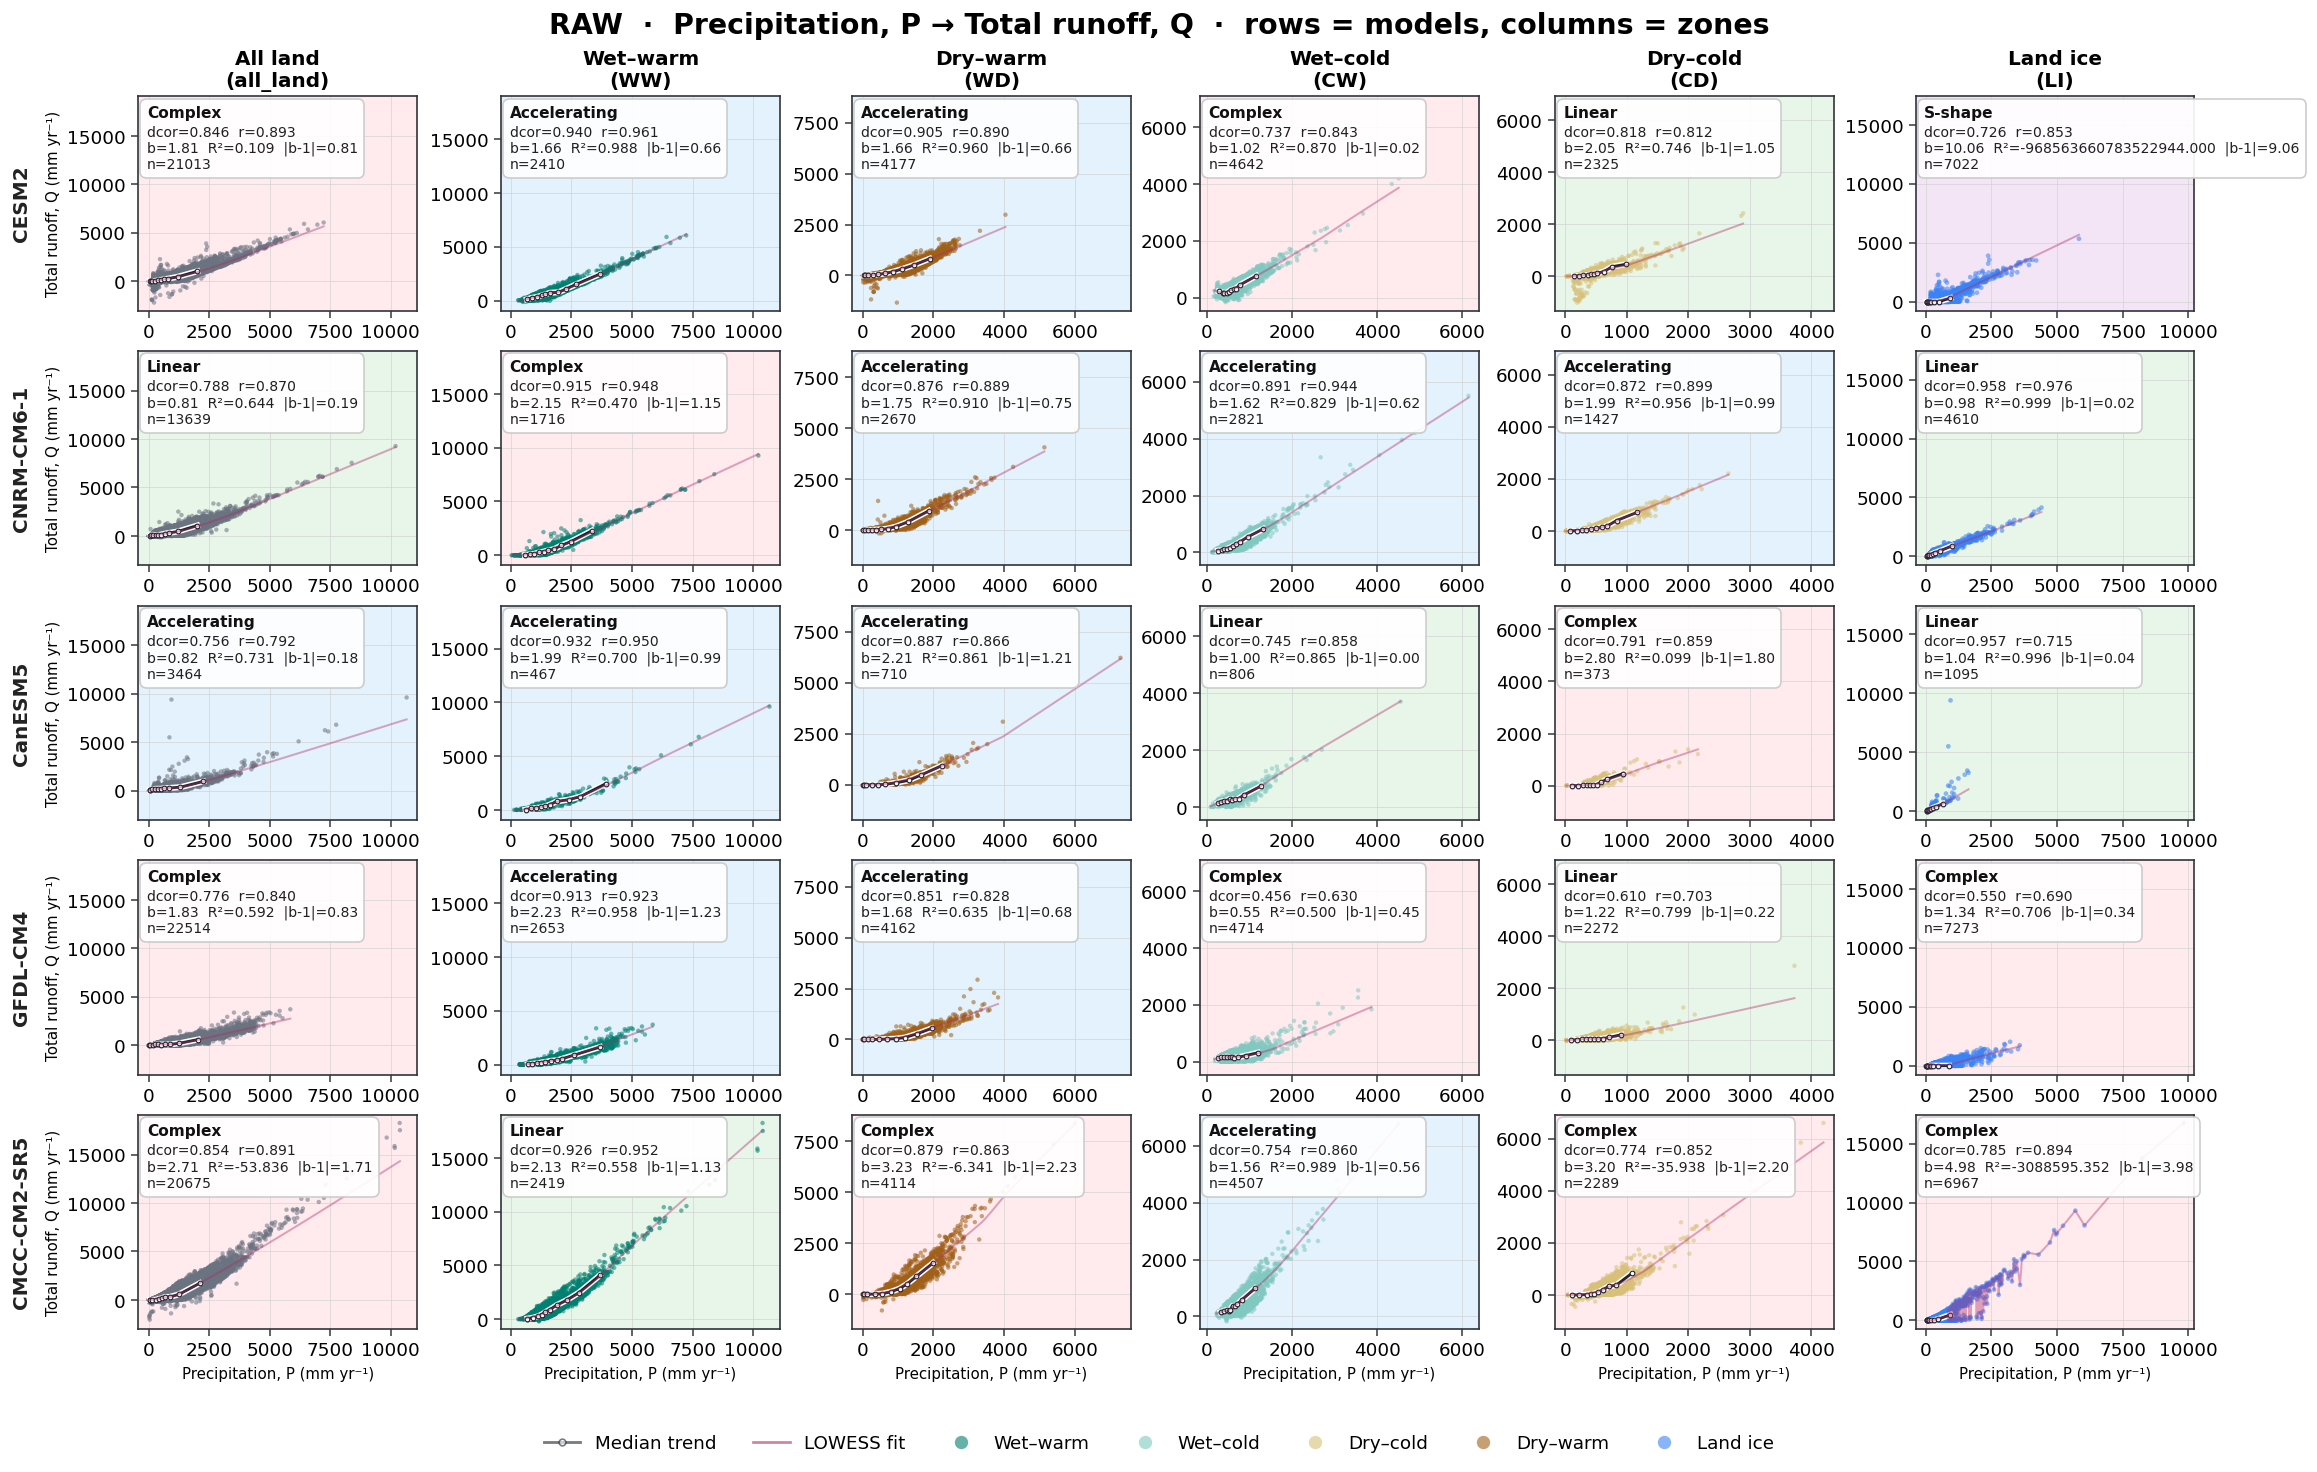


RAW grid · mrros → Q
saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4/figures/S4_modelgrid_mrros_Q_raw.png


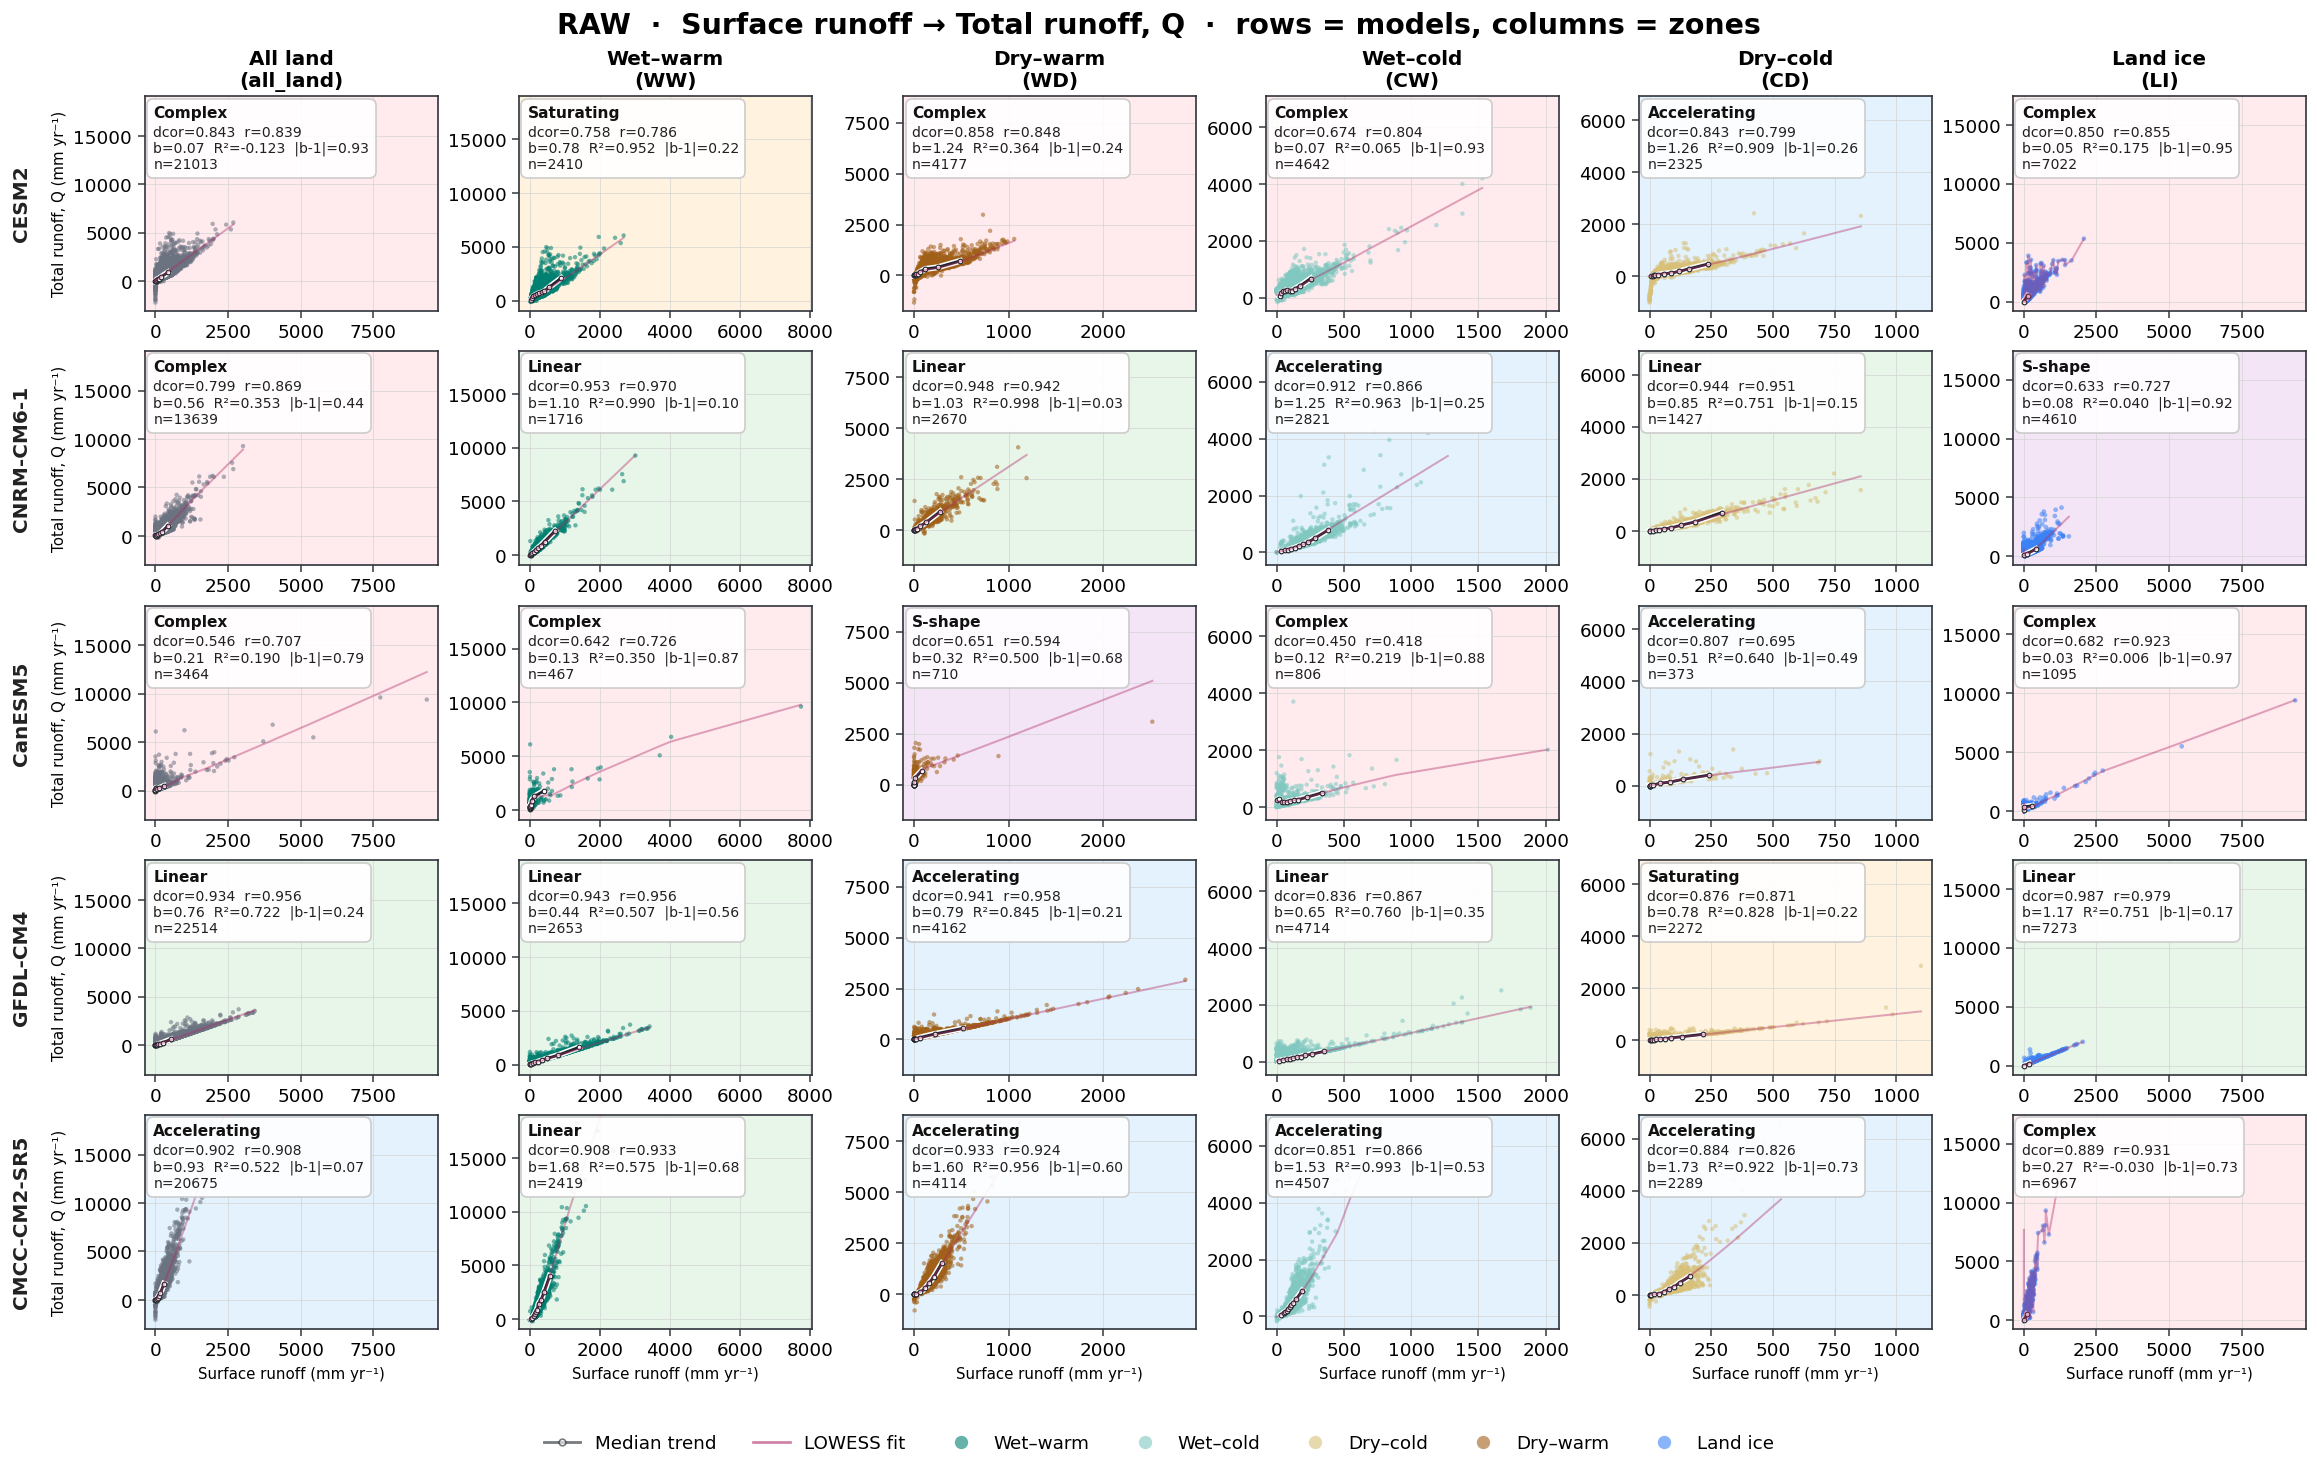


RAW grid · hfls → Q
saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4/figures/S4_modelgrid_hfls_Q_raw.png


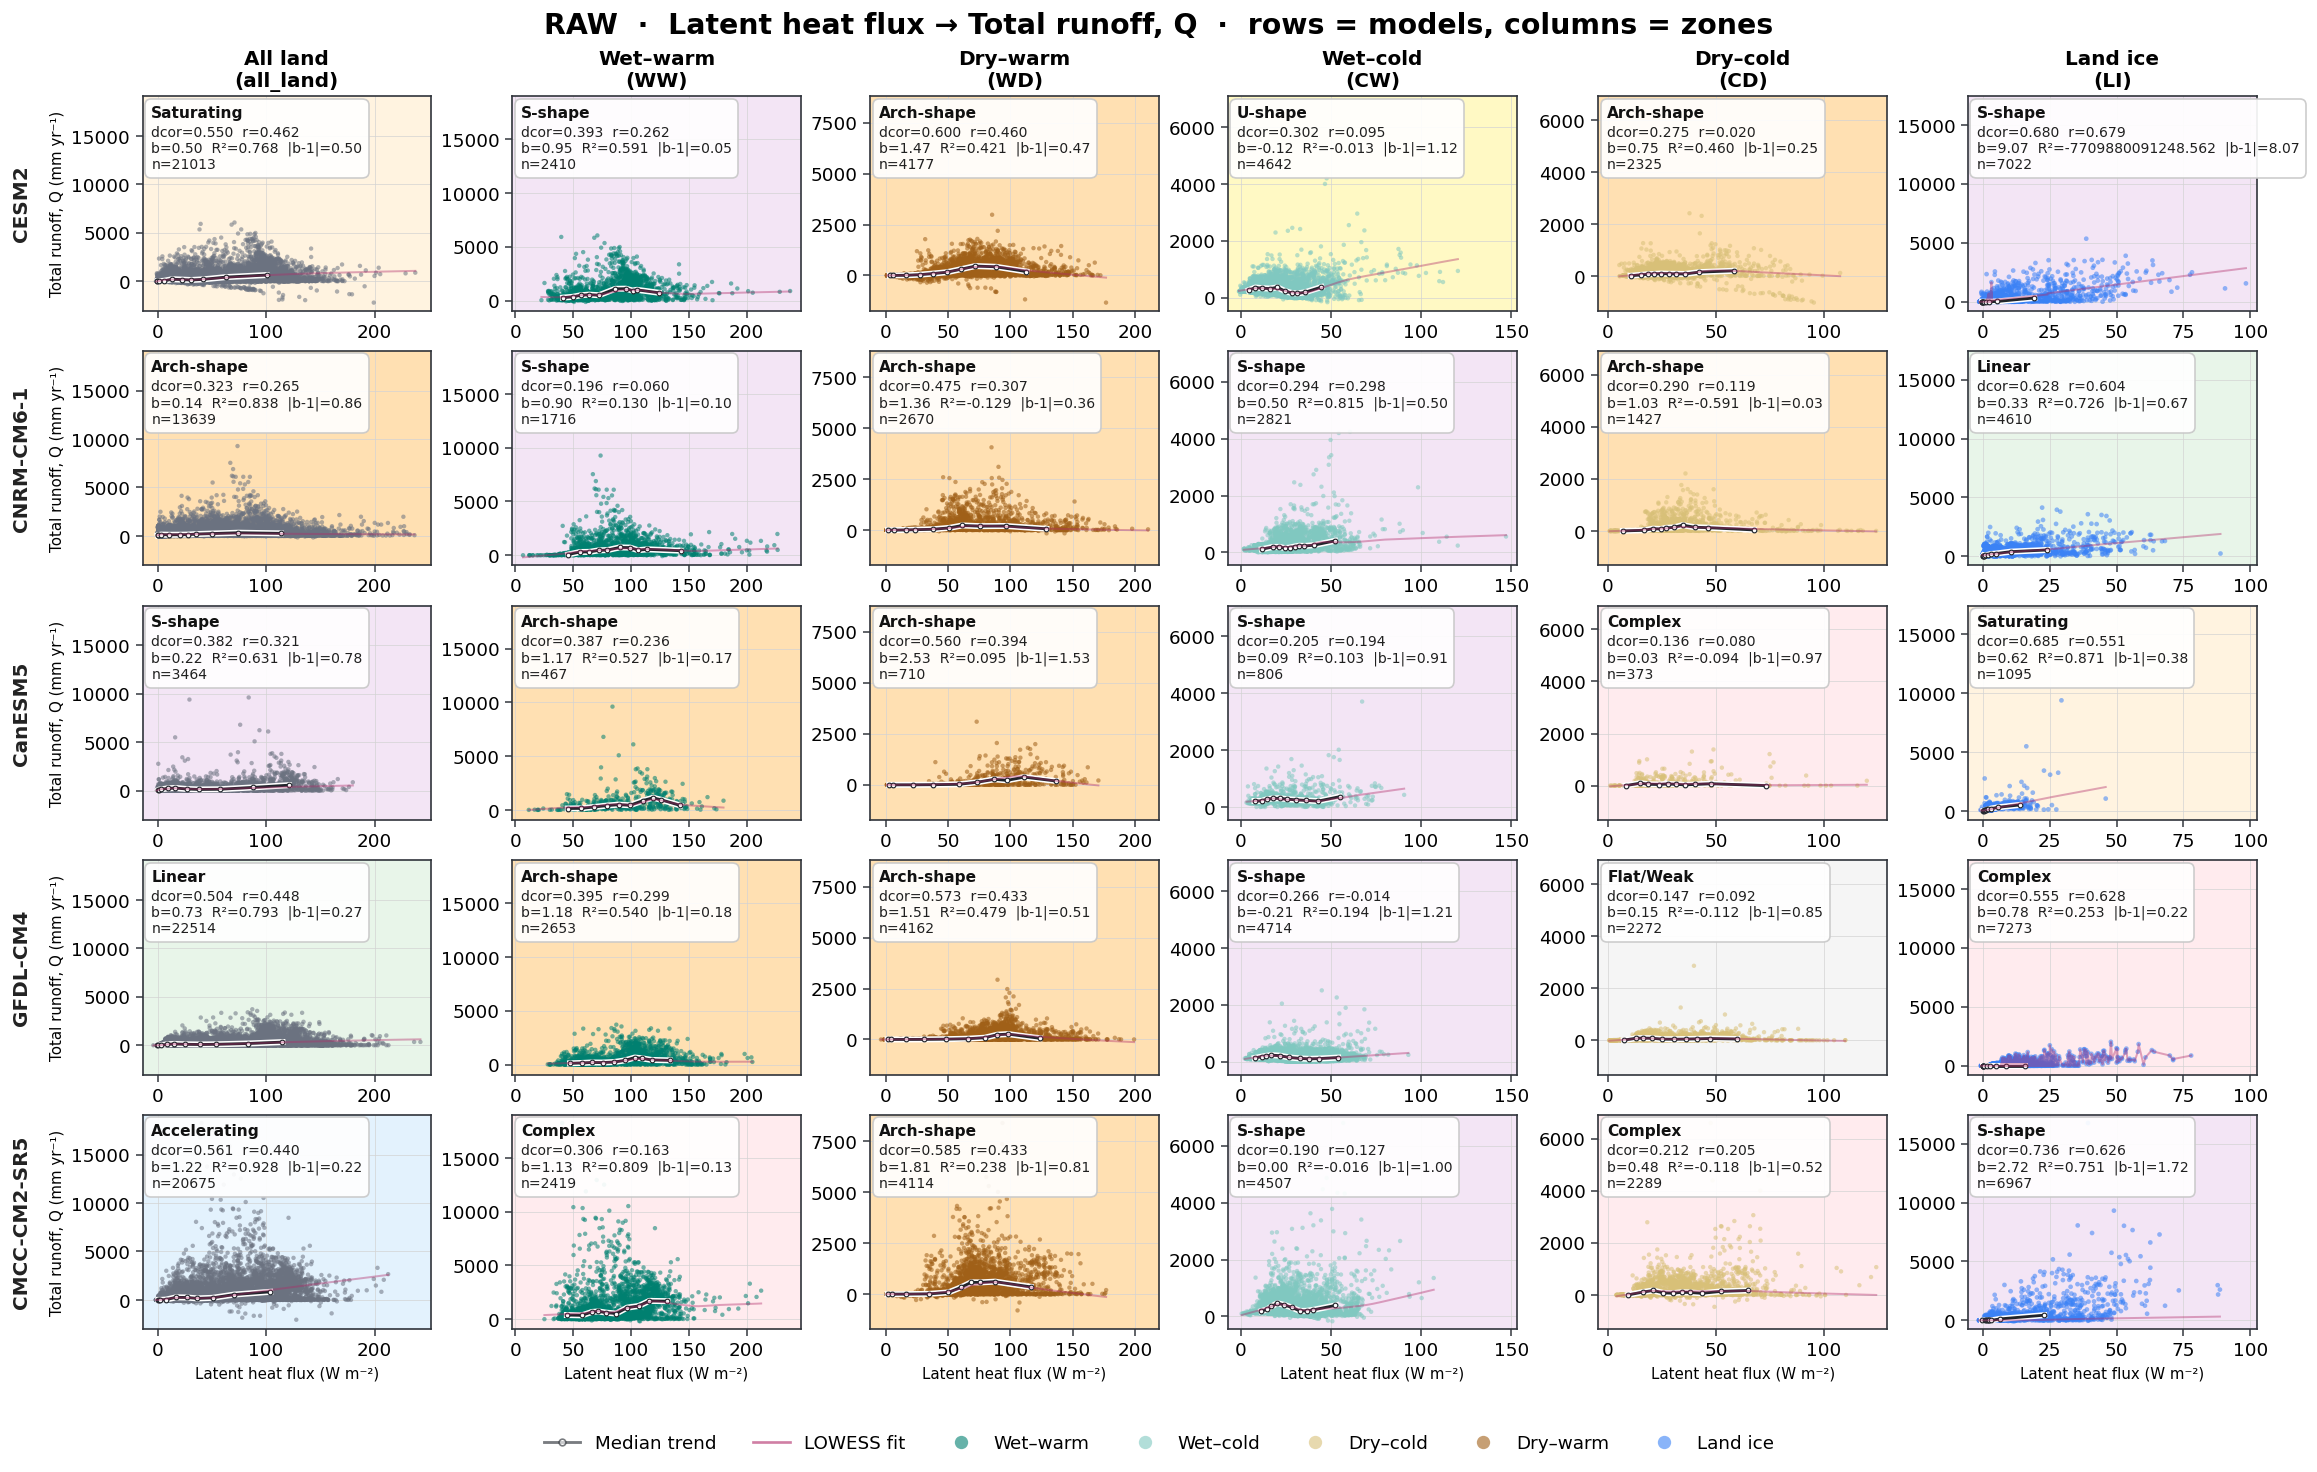

In [115]:
def _ensure_payloads(run):
    payloads = run.get('panel_payloads')
    if payloads is None:
        payloads = build_panel_payloads(run)
        run['panel_payloads'] = payloads
    return payloads


def _raw_count(run, pair_label, domain_key):
    payload = _ensure_payloads(run).get((pair_label, domain_key))
    if payload is None:
        return 0
    return len(payload['prepared']['raw'][0])


def column_limits_for_pair(pair_label, domain_key, runs, version='raw'):
    xs, ys = [], []
    for run in runs:
        payload = _ensure_payloads(run).get((pair_label, domain_key))
        if payload is None:
            continue
        xv, yv = payload['prepared'][version]
        if len(xv) == 0:
            continue
        xs.append(xv)
        ys.append(yv)
    if not xs:
        return (-1.0, 1.0), (-1.0, 1.0)
    return padded_limits(np.concatenate(xs)), padded_limits(np.concatenate(ys))


def select_grid_runs(pair_label):
    keep, skipped = [], []
    for run in RUNS:
        n_any = sum(
            _raw_count(run, pair_label, domain_key)
            for domain_key, _, _ in DOMAINS
        )
        n_not_all_land = sum(
            _raw_count(run, pair_label, domain_key)
            for domain_key, _, _ in DOMAINS
            if domain_key != 'all_land'
        )
        if n_not_all_land == 0:
            skipped.append(run['model'])
            continue
        if n_any == 0:
            skipped.append(run['model'])
            continue
        keep.append(run)
    if skipped:
        print(f'  omit empty models from overview: {", ".join(skipped)}')
    return keep


def select_grid_domains(pair_label, runs):
    keep = []
    for domain in DOMAINS:
        if any(_raw_count(run, pair_label, domain[0]) > 0 for run in runs):
            keep.append(domain)
    return keep


SHAPE_FACECOLORS = {
    'Linear':       '#E8F5E9',
    'Saturating':   '#FFF3E0',
    'Accelerating': '#E3F2FD',
    'S-shape':      '#F3E5F5',
    'Flat/Weak':    '#F5F5F5',
    'U-shape':      '#FFF9C4',
    'Arch-shape':   '#FFE0B2',
    'Complex':      '#FFEBEE',
    'Insufficient data': '#FFFFFF',
}


def draw_model_zone_grid(x_var, y_var, pair_label, version):
    grid_runs = select_grid_runs(pair_label)
    grid_domains = select_grid_domains(pair_label, grid_runs)
    n_rows = len(grid_runs)
    n_cols = len(grid_domains)
    if n_rows == 0 or n_cols == 0:
        print(f'No models with data for {pair_label} {version}')
        return

    col_limits = {
        domain_key: column_limits_for_pair(pair_label, domain_key, grid_runs, version)
        for domain_key, _, _ in grid_domains
    }

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.2 * n_cols, 2.3 * n_rows),
        constrained_layout=True,
        squeeze=False,
    )

    for row_i, run in enumerate(grid_runs):
        payloads = _ensure_payloads(run)

        for col_i, (domain_key, domain_label, _) in enumerate(grid_domains):
            ax = axes[row_i, col_i]
            payload = payloads[(pair_label, domain_key)]
            x_data, y_data = payload['prepared'][version]
            groups = payload['prepared'][f'{version}_groups']
            scatter_points(ax, x_data, y_data, domain_key, groups)

            bin_curve = equal_count_bin_medians(x_data, y_data)
            if len(bin_curve) >= 2:
                ax.plot(
                    bin_curve['x'], bin_curve['y'],
                    color='white', linewidth=3.6, zorder=3,
                )
                ax.plot(
                    bin_curve['x'], bin_curve['y'],
                    color='#20252B', linewidth=1.7, marker='o',
                    markersize=2.8, markerfacecolor='white',
                    markeredgecolor='#20252B', markeredgewidth=0.7,
                    zorder=4,
                )
            draw_lowess_fit(ax, x_data, y_data)

            # LOWESS shape classification
            feat = extract_lowess_shape(x_data, y_data)
            shape_label = classify_lowess_shape(feat)

            # Build annotation with power-law metrics
            version_rows = payload['result_rows'].loc[
                payload['result_rows']['outlier_version'] == version
            ]
            if len(version_rows) == 1:
                result_row = version_rows.iloc[0]
                line1 = (
                    f"dcor={metric_text(result_row, 'dcor')}  "
                    f"r={metric_text(result_row, 'pearson_r_descriptive')}"
                )
            else:
                line1 = ''
            if feat is not None and np.isfinite(feat.get('power_b', np.nan)):
                line2 = (
                    f"b={feat['power_b']:.2f}  "
                    f"R²={feat['power_r2']:.3f}  "
                    f"|b-1|={feat['abs_b_minus_1']:.2f}"
                )
            else:
                line2 = ''
            line3 = f"n={len(x_data)}"
            parts = [p for p in [line1, line2, line3] if p]
            details = '\n'.join(parts)
            draw_class_annotation(ax, shape_label, details, fontsize=8.4)

            xlim, ylim = col_limits[domain_key]
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            style_axes(ax)
            ax.set_facecolor(SHAPE_FACECOLORS.get(shape_label, '#FFFFFF'))

            if row_i == 0:
                ax.set_title(
                    f'{domain_label}\n({domain_key})',
                    fontsize=12, fontweight='semibold', pad=6,
                )
            if col_i == 0:
                ax.set_ylabel(UNIT_LABELS[y_var], fontsize=9)
                ax.text(
                    -0.42, 0.5, run['model'],
                    transform=ax.transAxes, rotation=90,
                    va='center', ha='center',
                    fontsize=12, fontweight='bold', color='#222222',
                )
            if row_i == n_rows - 1:
                ax.set_xlabel(UNIT_LABELS[x_var], fontsize=9)

    fig.suptitle(
        f'{version.upper()}  ·  {PAIR_FULL_NAMES.get(pair_label, pair_label)}  ·  rows = models, columns = zones',
        fontsize=17, fontweight='semibold',
    )
    legend_handles = [
        Line2D(
            [0], [0], color='#20252B', linewidth=1.7, marker='o',
            markersize=4, markerfacecolor='white', alpha=0.6,
            label='Median trend',
        ),
        Line2D(
            [0], [0], color='#B12A68', linewidth=1.6,
            linestyle='-', alpha=0.6,
            label='LOWESS fit',
        ),
    ]
    for key, label in ZONE_LEGEND:
        legend_handles.append(
            Line2D(
                [0], [0], marker='o', color='none',
                markerfacecolor=ZONE_COLORS[key], markeredgecolor='none',
                markersize=8, alpha=0.6, label=label,
            )
        )

    fig.legend(
        handles=legend_handles, loc='lower center',
        ncol=min(8, len(legend_handles)),
        bbox_to_anchor=(0.5, -0.06), frameon=True, fancybox=True, framealpha=0.5, edgecolor='none', fontsize=11,
    )
    if WRITE_OUTPUTS:
        path = FIGURE_DIR / (
            f'S4_modelgrid_{PAIR_SLUGS[pair_label]}_{version}.png'
        )
        fig.savefig(path, dpi=160, bbox_inches='tight')
        print(f'saved {path}')
    plt.show()
    plt.close(fig)


print('Model × zone grids — RAW')
print('=' * 72)
for x_var, y_var, pair_label in VARIABLE_PAIRS:
    print(f'\nRAW grid · {pair_label}')
    draw_model_zone_grid(x_var, y_var, pair_label, 'raw')


## 6f. Model × zone grid — TRIMMED / 模型×分区总图（trimmed）

Same layout as 6e, trimmed version.

**中文说明：** 与6e相同布局的trimmed版本。

In [116]:
# print('Model × zone grids — TRIMMED')
# print('=' * 72)
# for x_var, y_var, pair_label in VARIABLE_PAIRS:
#     print(f'\nTRIMMED grid · {pair_label}')
#     draw_model_zone_grid(x_var, y_var, pair_label, 'trimmed')


## 6g. Model × zone grid — GLOBAL TRIMMED / 模型×分区总图（全局去极值）

Same layout as 6f, using global (all_land) quantile bounds.

**中文说明：** 与6f相同布局，使用全局分位数边界。

In [117]:
# def build_global_trim_bounds(run):
#     """Compute 1-99% quantile bounds from all_land for each variable pair."""
#     t = run['clim']
#     bounds = {}
#     for x_var, y_var, pair_label in VARIABLE_PAIRS:
#         if x_var not in t.columns or y_var not in t.columns:
#             continue
#         x_all = np.asarray(t[x_var], dtype=float)
#         y_all = np.asarray(t[y_var], dtype=float)
#         finite = np.isfinite(x_all) & np.isfinite(y_all)
#         xf, yf = x_all[finite], y_all[finite]
#         if len(xf) == 0:
#             bounds[(x_var, y_var)] = (np.nan, np.nan, np.nan, np.nan)
#         else:
#             x_lo, x_hi = np.quantile(xf, [TRIM_LOWER_QUANTILE, TRIM_UPPER_QUANTILE])
#             y_lo, y_hi = np.quantile(yf, [TRIM_LOWER_QUANTILE, TRIM_UPPER_QUANTILE])
#             bounds[(x_var, y_var)] = (float(x_lo), float(x_hi), float(y_lo), float(y_hi))
#     return bounds


# def build_panel_payloads_global(run):
#     """Like build_panel_payloads but uses all_land trim bounds for every domain."""
#     t = run['clim']
#     global_bounds = build_global_trim_bounds(run)
#     payloads = {}
#     for x_var, y_var, pair_label in VARIABLE_PAIRS:
#         if (x_var, y_var) not in global_bounds:
#             continue
#         gb = global_bounds[(x_var, y_var)]
#         x_lo, x_hi, y_lo, y_hi = gb
#         for domain_key, domain_label, domain_filter in DOMAINS:
#             subset = t.loc[domain_filter(t)] if domain_filter is not None else t
#             x_arr = np.asarray(subset[x_var], dtype=float)
#             y_arr = np.asarray(subset[y_var], dtype=float)
#             groups = np.asarray(subset['analysis_zone']) if 'analysis_zone' in subset else None
#             finite = np.isfinite(x_arr) & np.isfinite(y_arr)
#             x_raw = x_arr[finite]
#             y_raw = y_arr[finite]
#             g_raw = groups[finite] if groups is not None else None
#             if len(x_raw) == 0 or np.isnan(x_lo):
#                 keep = np.zeros(len(x_raw), dtype=bool)
#             else:
#                 keep = (
#                     (x_raw >= x_lo) & (x_raw <= x_hi)
#                     & (y_raw >= y_lo) & (y_raw <= y_hi)
#                 )
#             x_trim = x_raw[keep]
#             y_trim = y_raw[keep]
#             g_trim = g_raw[keep] if g_raw is not None else None
#             prepared = {
#                 'raw': (x_raw, y_raw),
#                 'trimmed': (x_trim, y_trim),
#                 'raw_groups': g_raw,
#                 'trimmed_groups': g_trim,
#                 'trim_keep': keep,
#                 'bounds': gb,
#             }
#             result_rows = RESULTS_DF.loc[
#                 (RESULTS_DF['model'] == run['model'])
#                 & (RESULTS_DF['experiment'] == run['experiment'])
#                 & (RESULTS_DF['member'] == run['member'])
#                 & (RESULTS_DF['grid'] == run['grid'])
#                 & (RESULTS_DF['domain'] == domain_key)
#                 & (RESULTS_DF['sample'] == 'all')
#                 & (RESULTS_DF['x_var'] == x_var)
#                 & (RESULTS_DF['y_var'] == y_var)
#             ]
#             payloads[(pair_label, domain_key)] = {
#                 'x_var': x_var,
#                 'y_var': y_var,
#                 'pair_label': pair_label,
#                 'domain_key': domain_key,
#                 'domain_label': domain_label,
#                 'prepared': prepared,
#                 'result_rows': result_rows,
#                 'xlim': padded_limits(x_trim),
#                 'ylim': padded_limits(y_trim),
#             }
#     return payloads


# def draw_model_zone_grid_global(x_var, y_var, pair_label):
#     """Model x zone grid using global trim bounds, showing only kept points."""
#     grid_runs = select_grid_runs(pair_label)
#     grid_domains = select_grid_domains(pair_label, grid_runs)
#     n_rows = len(grid_runs)
#     n_cols = len(grid_domains)
#     if n_rows == 0 or n_cols == 0:
#         print(f'No models with data for {pair_label} global-trimmed')
#         return

#     all_payloads = {}
#     for run in grid_runs:
#         all_payloads[run['model']] = build_panel_payloads_global(run)

#     col_limits = {}
#     for domain_key, _, _ in grid_domains:
#         xs, ys = [], []
#         for run in grid_runs:
#             p = all_payloads[run['model']].get((pair_label, domain_key))
#             if p is None:
#                 continue
#             xt, yt = p['prepared']['trimmed']
#             if len(xt) > 0:
#                 xs.append(xt)
#                 ys.append(yt)
#         if xs:
#             col_limits[domain_key] = (
#                 padded_limits(np.concatenate(xs)),
#                 padded_limits(np.concatenate(ys)),
#             )
#         else:
#             col_limits[domain_key] = ((-1.0, 1.0), (-1.0, 1.0))

#     fig, axes = plt.subplots(
#         n_rows, n_cols,
#         figsize=(3.2 * n_cols, 2.3 * n_rows),
#         constrained_layout=True,
#         squeeze=False,
#     )

#     for row_i, run in enumerate(grid_runs):
#         payloads = all_payloads[run['model']]
#         for col_i, (domain_key, domain_label, _) in enumerate(grid_domains):
#             ax = axes[row_i, col_i]
#             payload = payloads.get((pair_label, domain_key))
#             if payload is None:
#                 ax.text(
#                     0.5, 0.5, 'Unavailable', transform=ax.transAxes,
#                     ha='center', va='center', fontsize=12, color='#6B7280',
#                 )
#                 style_axes(ax)
#                 continue
#             x_data, y_data = payload['prepared']['trimmed']
#             groups = payload['prepared']['trimmed_groups']
#             scatter_points(ax, x_data, y_data, domain_key, groups)

#             bin_curve = equal_count_bin_medians(x_data, y_data)
#             if len(bin_curve) >= 2:
#                 ax.plot(
#                     bin_curve['x'], bin_curve['y'],
#                     color='white', linewidth=3.6, zorder=3,
#                 )
#                 ax.plot(
#                     bin_curve['x'], bin_curve['y'],
#                     color='#20252B', linewidth=1.7, marker='o',
#                     markersize=2.8, markerfacecolor='white',
#                     markeredgecolor='#20252B', markeredgewidth=0.7,
#                     zorder=4,
#                 )
#             draw_lowess_fit(ax, x_data, y_data)

#             version_rows = payload['result_rows'].loc[
#                 payload['result_rows']['outlier_version'] == 'trimmed'
#             ]
#             raw_rows = payload['result_rows'].loc[
#                 payload['result_rows']['outlier_version'] == 'raw'
#             ]
#             if len(version_rows) == 1:
#                 result_row = version_rows.iloc[0]
#                 raw_row = raw_rows.iloc[0] if len(raw_rows) == 1 else None
#                 class_name, details = format_panel_annotation(
#                     result_row, 'trimmed', raw_row=raw_row
#                 )
#             else:
#                 class_name, details = 'No result', ''
#             draw_class_annotation(ax, class_name, details, fontsize=8.4)

#             xlim, ylim = col_limits[domain_key]
#             ax.set_xlim(xlim)
#             ax.set_ylim(ylim)
#             style_axes(ax)
#             face = '#FFFFFF'
#             if len(version_rows) == 1:
#                 face = classification_facecolor(version_rows.iloc[0]['group'])
#             ax.set_facecolor(face)

#             if row_i == 0:
#                 ax.set_title(
#                     f'{domain_label}\n({domain_key})',
#                     fontsize=12, fontweight='semibold', pad=6,
#                 )
#             if col_i == 0:
#                 ax.set_ylabel(UNIT_LABELS[y_var], fontsize=9)
#                 ax.text(
#                     -0.42, 0.5, run['model'],
#                     transform=ax.transAxes, rotation=90,
#                     va='center', ha='center',
#                     fontsize=12, fontweight='bold', color='#222222',
#                 )
#             if row_i == n_rows - 1:
#                 ax.set_xlabel(UNIT_LABELS[x_var], fontsize=9)

#     fig.suptitle(
#         f'GLOBAL TRIMMED  ·  {PAIR_FULL_NAMES.get(pair_label, pair_label)}  ·  rows = models, columns = zones',
#         fontsize=17, fontweight='semibold',
#     )
#     legend_handles = [
#         Line2D(
#             [0], [0], color='#20252B', linewidth=1.7, marker='o',
#             markersize=4, markerfacecolor='white', alpha=0.6,
#             label='Median trend',
#         ),
#         Line2D(
#             [0], [0], color='#B12A68', linewidth=1.6,
#             linestyle='-', alpha=0.6,
#             label='LOWESS fit',
#         ),
#     ]
#     for key, label in ZONE_LEGEND:
#         legend_handles.append(
#             Line2D(
#                 [0], [0], marker='o', color='none',
#                 markerfacecolor=ZONE_COLORS[key], markeredgecolor='none',
#                 markersize=8, alpha=0.6, label=label,
#             )
#         )
#     fig.legend(
#         handles=legend_handles, loc='lower center',
#         ncol=min(7, len(legend_handles)),
#         bbox_to_anchor=(0.5, -0.06), frameon=True, fancybox=True, framealpha=0.5, edgecolor='none', fontsize=11,
#     )
#     if WRITE_OUTPUTS:
#         path = FIGURE_DIR / (
#             f'S4_modelgrid_{PAIR_SLUGS[pair_label]}_global_trimmed.png'
#         )
#         fig.savefig(path, dpi=160, bbox_inches='tight')
#         print(f'saved {path}')
#     plt.show()
#     plt.close(fig)


# print('Model × zone grids — GLOBAL TRIMMED')
# print('=' * 72)
# for x_var, y_var, pair_label in VARIABLE_PAIRS:
#     print(f'\nGLOBAL TRIMMED grid · {pair_label}')
#     draw_model_zone_grid_global(x_var, y_var, pair_label)


## 7. Classification heatmap — RAW / raw分类热力图

One heatmap per model for **raw** classifications (domain × variable pair). Trimmed heatmaps follow in the next section.

**中文说明：** 每个模型先画一张raw热力图；全部raw热力图完成后再画trimmed。


In [118]:
# [COMMENTED OUT — not needed for variable screening]
# To restore, remove the leading "# " from each line below.
# domain_order = [d[0] for d in DOMAINS]
# pair_order = [v[2] for v in VARIABLE_PAIRS]
# GROUP_COLORS = {
#     'Linear': '#4CAF50',
#     'Saturation': '#FF9800',
#     'Acceleration': '#F44336',
#     'U-shape': '#9C27B0',
#     'Cubic': '#3F51B5',
#     'Oscillation': '#00BCD4',
#     'Branch': '#795548',
#     'Transition': '#607D8B',
#     'No Global Relationship': '#BDBDBD',
#     'Uncertain': '#E0E0E0',
#     'Insufficient data': '#F3F4F6',
# }
# 
# 
# def draw_classification_heatmap(ax, result_table, version):
#     version_table = result_table.loc[
#         (result_table['sample'] == 'all')
#         & (result_table['outlier_version'] == version)
#     ]
#     pivot_group = version_table.pivot_table(
#         index='domain', columns='pair', values='group', aggfunc='first',
#     ).reindex(index=domain_order, columns=pair_order)
#     pivot_mic = version_table.pivot_table(
#         index='domain', columns='pair', values='mic', aggfunc='first',
#     ).reindex(index=domain_order, columns=pair_order)
# 
#     ax.set_xlim(-0.5, len(pair_order) - 0.5)
#     ax.set_ylim(-0.5, len(domain_order) - 0.5)
#     ax.invert_yaxis()
#     ax.set_xticks(range(len(pair_order)))
#     ax.set_xticklabels(pair_order)
#     ax.set_yticks(range(len(domain_order)))
#     ax.set_yticklabels([d[1] for d in DOMAINS])
#     for yi, domain in enumerate(domain_order):
#         for xi, pair in enumerate(pair_order):
#             group_value = pivot_group.loc[domain, pair]
#             group = group_value if pd.notna(group_value) else ''
#             mic_val = pivot_mic.loc[domain, pair]
#             rect = plt.Rectangle(
#                 (xi - 0.48, yi - 0.45), 0.96, 0.9,
#                 facecolor=GROUP_COLORS.get(group, '#F5F5F5'),
#                 edgecolor='white', linewidth=2,
#             )
#             ax.add_patch(rect)
#             ax.text(xi, yi - 0.1, group, ha='center', va='center',
#                     fontsize=11, fontweight='semibold', color='#222222')
#             if pd.notna(mic_val):
#                 ax.text(xi, yi + 0.2, f'MIC={mic_val:.3f}',
#                         ha='center', va='center', fontsize=10, color='#555555')
#     ax.set_title(f'{version.upper()} classification',
#                  fontsize=14, fontweight='semibold', pad=10)
#     style_axes(ax)
#     ax.grid(False)
# 
# 
# def draw_heatmap_figure(run, version):
#     run_results = RESULTS_DF.loc[
#         (RESULTS_DF['model'] == run['model'])
#         & (RESULTS_DF['experiment'] == run['experiment'])
#         & (RESULTS_DF['member'] == run['member'])
#         & (RESULTS_DF['grid'] == run['grid'])
#     ]
#     fig, ax = plt.subplots(figsize=(10.5, 6.8), constrained_layout=True)
#     draw_classification_heatmap(ax, run_results, version)
#     fig.suptitle(
#         f"{version.upper()} spatial classifications · {run['model']}",
#         fontsize=14, fontweight='semibold',
#     )
#     if WRITE_OUTPUTS:
#         fig.savefig(
#             run['zones_dir'] / f'S4_classification_heatmap_{version}.png',
#             bbox_inches='tight',
#         )
#     plt.show()
#     plt.close(fig)
# 
# 
# print('RAW classification heatmaps')
# print('=' * 72)
# for run in RUNS:
#     draw_heatmap_figure(run, 'raw')
# 

## 7b. Classification heatmap — TRIMMED / trimmed分类热力图

Same domain × pair layout as the raw heatmaps, shown only after every model's raw heatmap.

**中文说明：** 与raw热力图布局相同，全部raw热力图完成后再显示。


In [119]:
# [COMMENTED OUT — not needed for variable screening]
# To restore, remove the leading "# " from each line below.
# print('TRIMMED classification heatmaps')
# print('=' * 72)
# for run in RUNS:
#     draw_heatmap_figure(run, 'trimmed')
# 

## 8. Sensitivity analysis / 敏感性分析

Two independent sensitivity checks are reported. First, all versus core is compared separately for raw and trimmed data to diagnose boundary mixing. Second, raw versus trimmed is compared for every domain × sample × pair to diagnose dependence on extreme grid cells. Raw remains the primary result.

**中文说明：** 这里分开检查两种敏感性：(1) 在raw和trimmed内部各自比较all与core，用于判断分区边界混合；(2) 对每个domain × sample × pair比较raw与trimmed，用于判断分类是否依赖极端格点。raw始终是主结果。


In [120]:
# [COMMENTED OUT — not needed for variable screening]
# To restore, remove the leading "# " from each line below.
# RUN_KEYS = ['model', 'experiment', 'member', 'grid']
# zone_domains = ['WW', 'WD', 'CW', 'CD']
# 
# # A. all versus core, evaluated separately inside raw and trimmed.
# core_sensitivity_rows = []
# for run_key, run_cases in RESULTS_DF.groupby(RUN_KEYS, sort=False):
#     run_meta = dict(zip(RUN_KEYS, run_key))
#     for version in ['raw', 'trimmed']:
#         version_cases = run_cases.loc[run_cases['outlier_version'] == version]
#         for domain in zone_domains:
#             for x_var, y_var, pair_label in VARIABLE_PAIRS:
#                 common = (
#                     (version_cases['domain'] == domain)
#                     & (version_cases['x_var'] == x_var)
#                     & (version_cases['y_var'] == y_var)
#                 )
#                 all_row = version_cases.loc[common & version_cases['sample'].eq('all')]
#                 core_row = version_cases.loc[common & version_cases['sample'].eq('core')]
#                 if len(all_row) != 1 or len(core_row) != 1:
#                     continue
#                 a = all_row.iloc[0]
#                 c = core_row.iloc[0]
#                 core_sensitivity_rows.append({
#                     **run_meta,
#                     'outlier_version': version,
#                     'domain': domain,
#                     'pair': pair_label,
#                     'all_n': a['n_cells'],
#                     'all_group': a['group'],
#                     'all_mic': a['mic'],
#                     'core_n': c['n_cells'],
#                     'core_group': c['group'],
#                     'core_mic': c['mic'],
#                     'consistent': a['group'] == c['group'],
#                 })
# 
# core_sensitivity_df = pd.DataFrame(core_sensitivity_rows)
# print('\n=== A. All vs core sensitivity ===')
# for _, _, pair_label in VARIABLE_PAIRS:
#     print(f'\n--- {pair_label} ---')
#     display(core_sensitivity_df.loc[
#         core_sensitivity_df['pair'] == pair_label,
#         ['domain', 'outlier_version', 'all_n', 'all_group', 'all_mic',
#          'core_n', 'core_group', 'core_mic', 'consistent'],
#     ].round(4))
# 
# # B. raw versus trimmed for every exact domain × sample × pair.
# outlier_sensitivity_rows = []
# unit_cols = RUN_KEYS + ['domain', 'sample', 'x_var', 'y_var', 'pair']
# for unit_key, unit_cases in RESULTS_DF.groupby(unit_cols, sort=False):
#     unit_meta = dict(zip(unit_cols, unit_key))
#     raw_row = unit_cases.loc[unit_cases['outlier_version'] == 'raw']
#     trimmed_row = unit_cases.loc[unit_cases['outlier_version'] == 'trimmed']
#     if len(raw_row) != 1 or len(trimmed_row) != 1:
#         continue
#     raw = raw_row.iloc[0]
#     trimmed = trimmed_row.iloc[0]
#     outlier_sensitivity_rows.append({
#         **unit_meta,
#         'raw_n': raw['n_cells'],
#         'trimmed_n': trimmed['n_cells'],
#         'n_removed': trimmed['n_removed'],
#         'removed_fraction': trimmed['removed_fraction'],
#         'raw_mic': raw.get('mic', np.nan),
#         'trimmed_mic': trimmed.get('mic', np.nan),
#         'raw_pearson': raw.get('pearson_r_descriptive', np.nan),
#         'trimmed_pearson': trimmed.get('pearson_r_descriptive', np.nan),
#         'raw_power_r2': raw.get('power_r2', np.nan),
#         'trimmed_power_r2': trimmed.get('power_r2', np.nan),
#         'raw_power_b': raw.get('power_b', np.nan),
#         'trimmed_power_b': trimmed.get('power_b', np.nan),
#         'raw_group': raw['group'],
#         'trimmed_group': trimmed['group'],
#         'consistent': raw['group'] == trimmed['group'],
#     })
# 
# outlier_sensitivity_df = pd.DataFrame(outlier_sensitivity_rows)
# print('\n=== B. Raw vs trimmed outlier sensitivity ===')
# outlier_display_cols = [
#     'domain', 'sample', 'raw_n', 'trimmed_n', 'n_removed',
#     'removed_fraction', 'raw_mic', 'trimmed_mic',
#     'raw_pearson', 'trimmed_pearson',
#     'raw_power_r2', 'trimmed_power_r2',
#     'raw_power_b', 'trimmed_power_b',
#     'raw_group', 'trimmed_group', 'consistent',
# ]
# for _, _, pair_label in VARIABLE_PAIRS:
#     print(f'\n--- {pair_label} ---')
#     display(outlier_sensitivity_df.loc[
#         outlier_sensitivity_df['pair'] == pair_label,
#         outlier_display_cols,
#     ].round(4))
# 
# n_changed = int((~outlier_sensitivity_df['consistent']).sum())
# print(f'\nRaw/trimmed classification changes: {n_changed} / {len(outlier_sensitivity_df)}')
# if n_changed > 0:
#     display(outlier_sensitivity_df.loc[
#         ~outlier_sensitivity_df['consistent'],
#         ['domain', 'sample', 'pair', 'raw_group', 'trimmed_group',
#          'removed_fraction'],
#     ].round(4))

## 6i. LOWESS shape classification / LOWESS 形态分类

Extract morphological features from each LOWESS curve (monotonicity, curvature, slope strength)
and assign a shape label: **Linear**, **Saturating**, **Accelerating**, **S-shape**, or **Flat/Weak**.

Results are stored in `LOWESS_SHAPE_DF` and saved alongside the classification results.

In [121]:
from scipy.interpolate import interp1d


def extract_lowess_shape(x_data, y_data, frac=0.3, it=3):
    """Fit LOWESS and extract shape features from the smoothed curve."""
    from scipy.signal import find_peaks

    x_arr = np.asarray(x_data, dtype=float)
    y_arr = np.asarray(y_data, dtype=float)
    finite = np.isfinite(x_arr) & np.isfinite(y_arr)
    xf, yf = x_arr[finite], y_arr[finite]
    if len(xf) < 20:
        return None

    result = _lowess(yf, xf, frac=frac, it=it, return_sorted=True)
    xs, ys = result[:, 0], result[:, 1]

    y_range = ys.max() - ys.min()
    x_range = xs.max() - xs.min()
    if x_range == 0 or y_range == 0:
        return None

    # Power-law fit on LOWESS curve: y = a * x^b
    # Fit in log-log space, evaluate R² in original space
    power_b = np.nan
    power_r2 = np.nan
    abs_b_minus_1 = np.nan
    pos_mask = (xs > 0) & (ys > 0)
    if pos_mask.sum() >= 10:
        log_x = np.log(xs[pos_mask])
        log_y = np.log(ys[pos_mask])
        coef = np.polyfit(log_x, log_y, 1)
        power_b = coef[0]
        abs_b_minus_1 = abs(power_b - 1.0)
        # R² in original space: power law prediction vs LOWESS curve
        y_pred = np.exp(np.polyval(coef, log_x))
        y_actual = ys[pos_mask]
        ss_res = np.sum((y_actual - y_pred) ** 2)
        ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
        power_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 1.0

    # First derivative
    dx = np.diff(xs)
    dy = np.diff(ys)
    mask = dx > 0
    dx, dy = dx[mask], dy[mask]
    if len(dx) < 5:
        return None
    slope = dy / dx

    # Second derivative
    x_mid = 0.5 * (xs[:-1][mask] + xs[1:][mask])
    dx2 = np.diff(x_mid)
    dslope = np.diff(slope)
    mask2 = dx2 > 0
    curvature = dslope[mask2] / dx2[mask2] if mask2.any() else np.array([])

    norm_slope = slope * (x_range / y_range)

    frac_positive = (slope > 0).mean()
    frac_negative = (slope < 0).mean()
    mean_norm_slope = norm_slope.mean()
    slope_std = norm_slope.std()

    n_edge = max(3, int(0.2 * len(slope)))
    slope_start = float(np.median(slope[:n_edge]))
    slope_end = float(np.median(slope[-n_edge:]))

    if len(curvature) > 0:
        frac_concave = (curvature > 0).mean()
        mean_curvature = float(np.mean(curvature * (x_range**2 / y_range)))
        half = len(curvature) // 2
        curv_first_half = curvature[:half].mean() if half > 0 else 0
        curv_second_half = curvature[half:].mean()
    else:
        frac_concave = np.nan
        mean_curvature = np.nan
        curv_first_half = 0
        curv_second_half = 0

    net_change = (ys[-1] - ys[0]) / y_range if y_range > 0 else 0

    # Turning points via find_peaks with prominence
    amplitude = np.ptp(ys)
    n_peaks, n_troughs = 0, 0
    if amplitude > 1e-10:
        prom = max(0.10 * amplitude, 1e-10)
        min_dist = max(5, int(0.08 * len(ys)))
        peaks, _ = find_peaks(ys, prominence=prom, distance=min_dist)
        troughs, _ = find_peaks(-ys, prominence=prom, distance=min_dist)
        n_peaks = len(peaks)
        n_troughs = len(troughs)

    return {
        'frac_positive_slope': frac_positive,
        'frac_negative_slope': frac_negative,
        'mean_norm_slope': mean_norm_slope,
        'slope_std': slope_std,
        'slope_start': slope_start,
        'slope_end': slope_end,
        'frac_concave': frac_concave,
        'mean_curvature': mean_curvature,
        'net_change': net_change,
        'curv_first_half': curv_first_half,
        'curv_second_half': curv_second_half,
        'power_b': power_b,
        'power_r2': power_r2,
        'abs_b_minus_1': abs_b_minus_1,
        'n_peaks': n_peaks,
        'n_troughs': n_troughs,
    }


def classify_lowess_shape(feat, flat_thresh=0.15):
    """Assign a shape label based on extracted LOWESS features."""
    if feat is None:
        return 'Insufficient data'

    net = feat['net_change']
    frac_pos = feat['frac_positive_slope']
    frac_neg = feat['frac_negative_slope']
    frac_concave = feat['frac_concave']
    power_b = feat['power_b']
    power_r2 = feat['power_r2']
    abs_b_1 = feat['abs_b_minus_1']
    n_peaks = feat['n_peaks']
    n_troughs = feat['n_troughs']
    n_tp = n_peaks + n_troughs

    # 1. Flat / Weak
    if abs(net) < flat_thresh:
        if n_peaks == 1 and n_troughs == 0:
            return 'Arch-shape'
        if n_troughs == 1 and n_peaks == 0:
            return 'U-shape'
        return 'Flat/Weak'

    # 2. Power-law fit first — if it fits well, use b to classify
    has_power = np.isfinite(power_b) and np.isfinite(power_r2)
    is_monotone_inc = frac_pos >= 0.80
    is_monotone_dec = frac_neg >= 0.80
    is_monotone = is_monotone_inc or is_monotone_dec

    if has_power and power_r2 >= 0.80 and is_monotone:
        if abs_b_1 < 0.15:
            return 'Linear'
        if power_b > 1.15:
            return 'Accelerating'
        if power_b < 0.85:
            # Cross-check: if curvature says concave-up, trust curvature
            if is_monotone_inc and frac_concave > 0.55:
                return 'Accelerating'
            return 'Saturating'

    # 3. Power-law fit poor — check turning points
    if n_tp >= 3:
        return 'Complex'
    if n_peaks == 1 and n_troughs == 0:
        return 'Arch-shape'
    if n_troughs == 1 and n_peaks == 0:
        return 'U-shape'
    if n_tp == 2:
        return 'S-shape'

    # 4. Monotone but power-law R² low — use curvature only if R² is moderate
    if is_monotone:
        if not has_power or power_r2 < 0.50:
            return 'Complex'
        if is_monotone_inc and frac_concave < 0.40:
            return 'Saturating'
        if is_monotone_dec and frac_concave > 0.60:
            return 'Saturating'
        if is_monotone_inc and frac_concave > 0.60:
            return 'Accelerating'
        if is_monotone_dec and frac_concave < 0.40:
            return 'Accelerating'
        return 'Linear'

    # 5. Non-monotone without clear turning points
    c1 = feat['curv_first_half']
    c2 = feat['curv_second_half']
    if c1 * c2 < 0:
        return 'S-shape'

    return 'Complex' 
# --- Run shape extraction on all model x zone x pair x version combos ---
shape_records = []
for run in RUNS:
    payloads = _ensure_payloads(run)
    for x_var, y_var, pair_label in VARIABLE_PAIRS:
        for domain_key, domain_label, _ in DOMAINS:
            payload = payloads.get((pair_label, domain_key))
            if payload is None:
                continue
            for version in ['raw', 'trimmed']:
                x_data, y_data = payload['prepared'][version]
                if len(x_data) < 20:
                    shape_records.append({
                        'model': run['model'], 'domain': domain_key,
                        'x_var': x_var, 'y_var': y_var,
                        'pair': pair_label, 'version': version,
                        'shape_label': 'Insufficient data', 'n_points': len(x_data),
                    })
                    continue
                feat = extract_lowess_shape(x_data, y_data)
                label = classify_lowess_shape(feat)
                rec = {
                    'model': run['model'], 'domain': domain_key,
                    'x_var': x_var, 'y_var': y_var,
                    'pair': pair_label, 'version': version,
                    'shape_label': label,
                    'n_points': len(x_data),
                }
                if feat is not None:
                    rec.update(feat)
                shape_records.append(rec)

LOWESS_SHAPE_DF = pd.DataFrame(shape_records)
print(f'LOWESS shape records: {len(LOWESS_SHAPE_DF)}')
print()
print('Shape label counts (all versions):')
print(LOWESS_SHAPE_DF['shape_label'].value_counts())
print()

for version in ['raw', 'trimmed']:
    print(f'\n=== {version.upper()} ===')
    sub = LOWESS_SHAPE_DF[LOWESS_SHAPE_DF['version'] == version]
    for pair_label in [p[2] for p in VARIABLE_PAIRS]:
        ps = sub[sub['pair'] == pair_label]
        print(f'\n{pair_label}:')
        ct = ps.pivot_table(
            index='model', columns='domain',
            values='shape_label', aggfunc='first',
        )
        col_order = [d[0] for d in DOMAINS if d[0] in ct.columns]
        print(ct[col_order].to_string())

if WRITE_OUTPUTS:
    shape_path = S4_OUTPUT_DIR / f'S4_lowess_shape_{START_YEAR}_{END_YEAR}.csv'
    LOWESS_SHAPE_DF.to_csv(shape_path, index=False)
    print(f'\nSaved: {shape_path}')


LOWESS shape records: 180

Shape label counts (all versions):
shape_label
Accelerating    47
Complex         43
Linear          33
S-shape         22
Arch-shape      22
Saturating       9
U-shape          3
Flat/Weak        1
Name: count, dtype: int64


=== RAW ===

P → Q:
domain            all_land            WW            WD            CW            CD       LI
model                                                                                      
CESM2              Complex  Accelerating  Accelerating       Complex        Linear  S-shape
CMCC-CM2-SR5       Complex        Linear       Complex  Accelerating       Complex  Complex
CNRM-CM6-1          Linear       Complex  Accelerating  Accelerating  Accelerating   Linear
CanESM5       Accelerating  Accelerating  Accelerating        Linear       Complex   Linear
GFDL-CM4           Complex  Accelerating  Accelerating       Complex        Linear  Complex

mrros → Q:
domain            all_land          WW            WD            CW    

## 6h. Density plots — KDE contour & 2D histogram / 密度图

Same model × zone grid layout as sections 6e–6g, but scatter points replaced by density visualisation.
Two methods: KDE contour and 2D histogram. Each runs for RAW, TRIMMED, and GLOBAL TRIMMED.

**中文说明：** 与6e–6g相同的模型×分区布局，散点替换为密度图。每种方法分别画RAW、TRIMMED、GLOBAL TRIMMED。


Density grids — Hexbin · RAW
  P → Q


KeyboardInterrupt: 

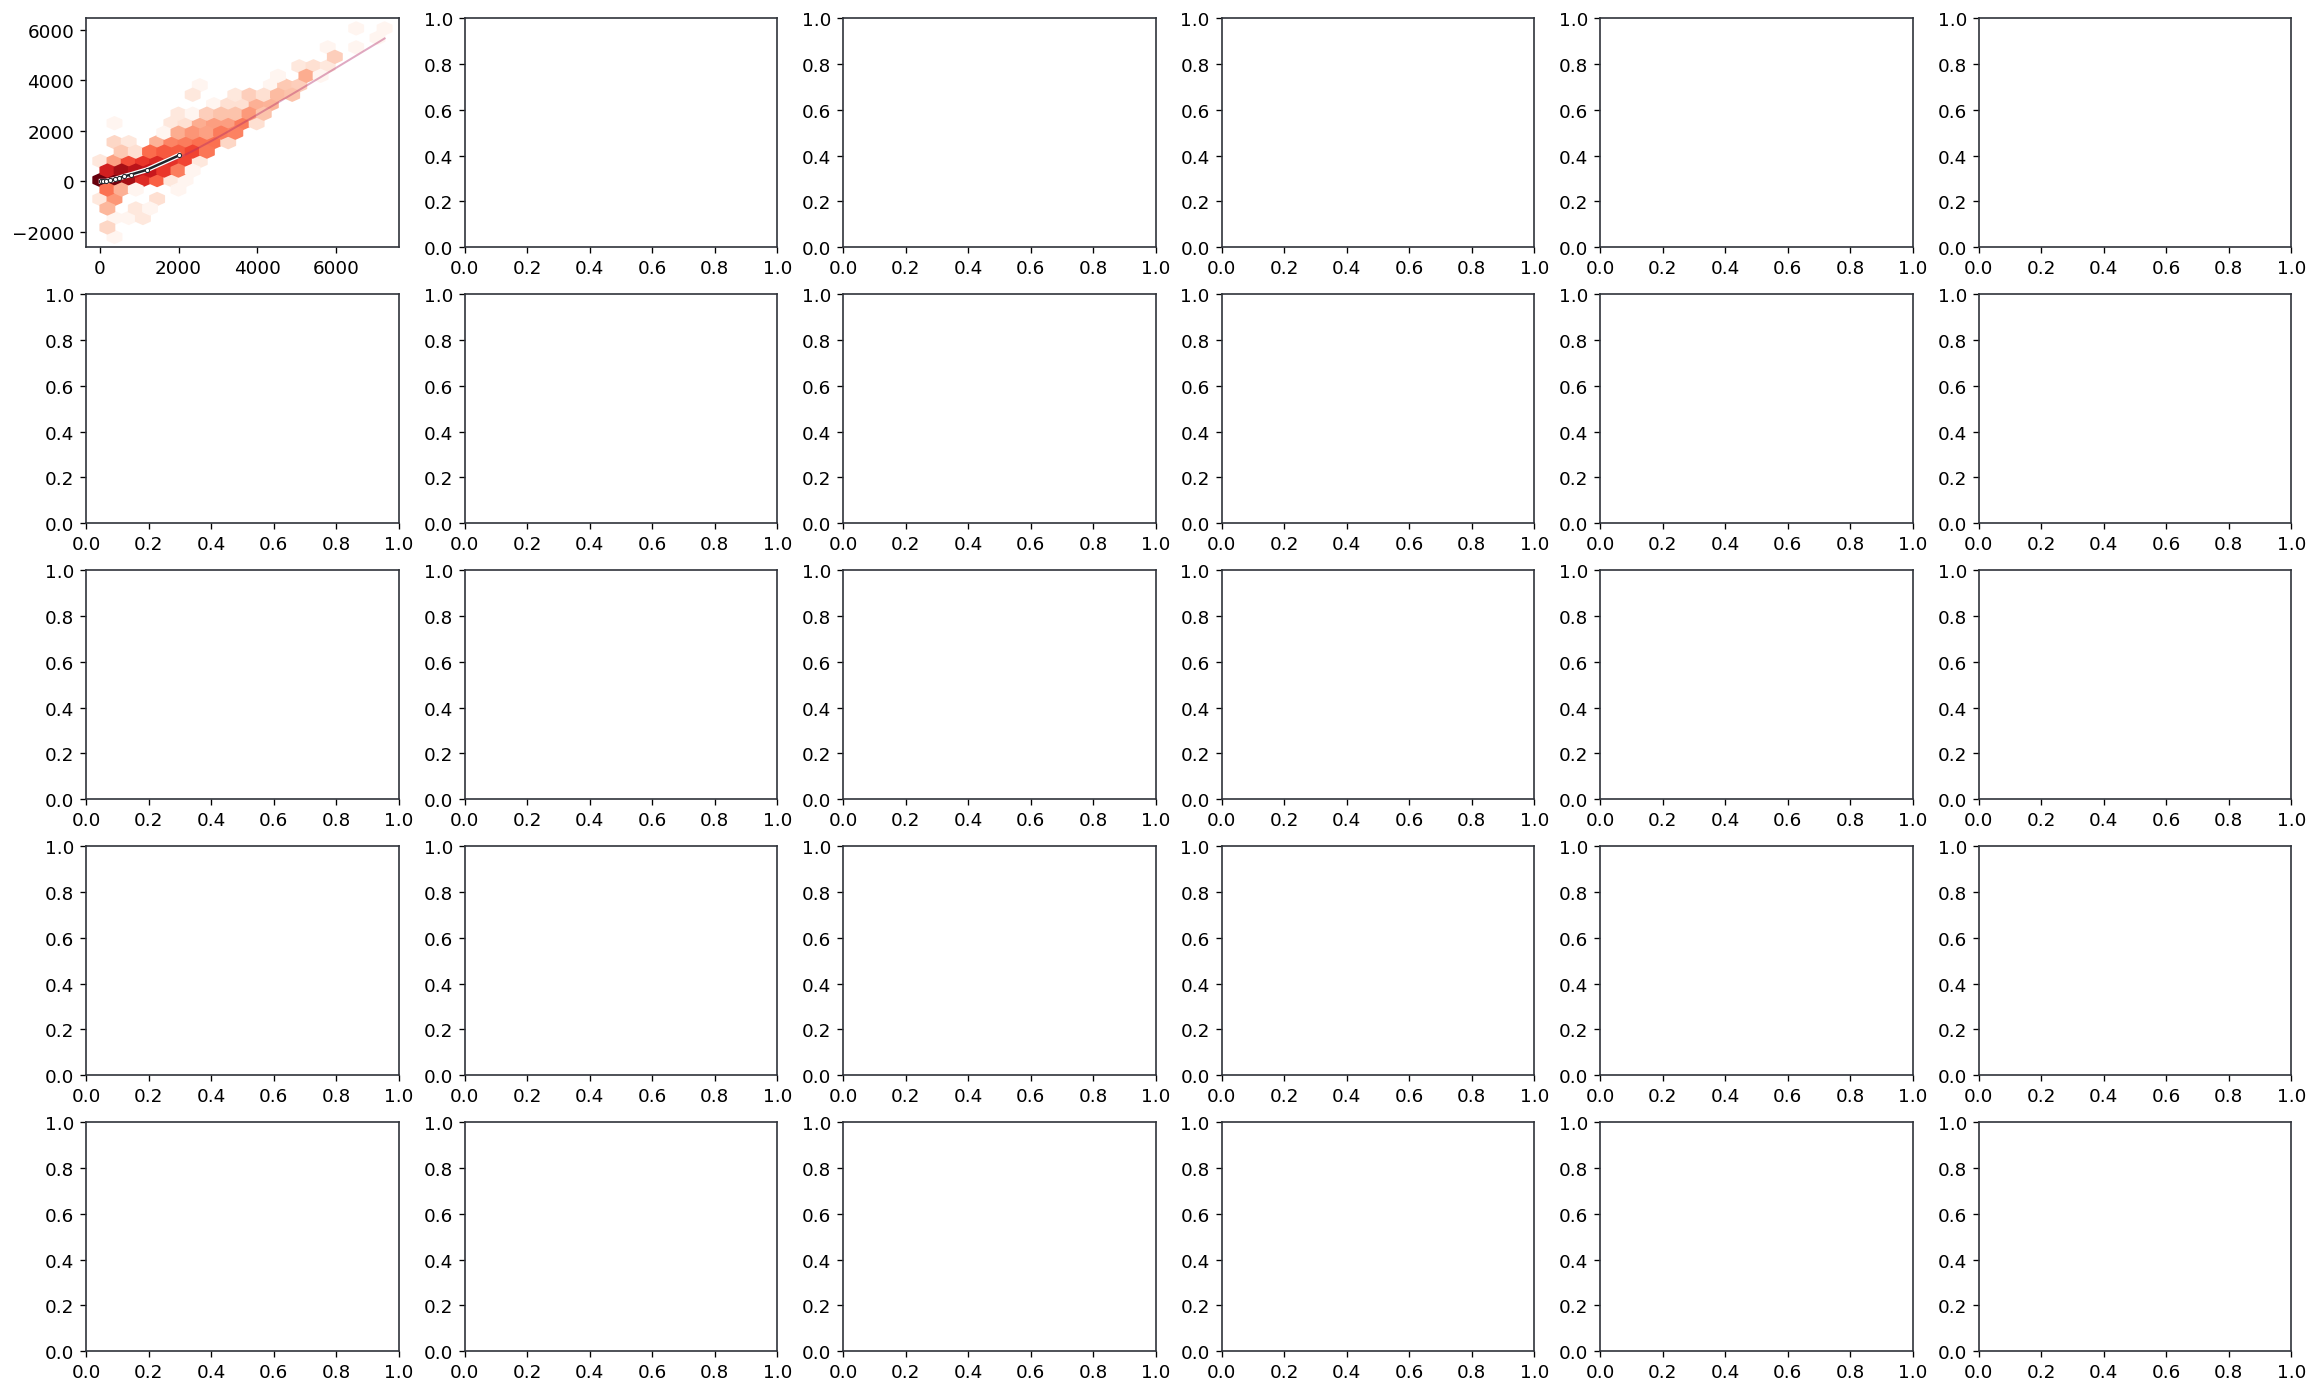

In [122]:
def draw_density_grid(x_var, y_var, pair_label, version, method='kde'):
    """Model × zone density grid. version: 'raw', 'trimmed', or 'global_trimmed'."""
    method_label = 'KDE' if method == 'kde' else 'Hexbin'
    version_label = version.upper().replace('_', ' ')

    if version == 'global_trimmed':
        grid_runs = select_grid_runs(pair_label)
        grid_domains = select_grid_domains(pair_label, grid_runs)
        all_payloads = {}
        for run in grid_runs:
            all_payloads[run['model']] = build_panel_payloads_global(run)
    else:
        grid_runs = select_grid_runs(pair_label)
        grid_domains = select_grid_domains(pair_label, grid_runs)

    n_rows = len(grid_runs)
    n_cols = len(grid_domains)
    if n_rows == 0 or n_cols == 0:
        print(f'No models with data for {pair_label} {version_label}')
        return

    if version != 'global_trimmed':
        col_limits = {
            dk: column_limits_for_pair(pair_label, dk, grid_runs, version)
            for dk, _, _ in grid_domains
        }
    else:
        col_limits = {}
        for dk, _, _ in grid_domains:
            xs, ys = [], []
            for run in grid_runs:
                p = all_payloads[run['model']].get((pair_label, dk))
                if p is None:
                    continue
                xt, yt = p['prepared']['trimmed']
                if len(xt) > 0:
                    xs.append(xt)
                    ys.append(yt)
            if xs:
                col_limits[dk] = (padded_limits(np.concatenate(xs)),
                                  padded_limits(np.concatenate(ys)))
            else:
                col_limits[dk] = ((-1.0, 1.0), (-1.0, 1.0))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.2 * n_cols, 2.3 * n_rows),
        constrained_layout=True, squeeze=False,
    )

    for row_i, run in enumerate(grid_runs):
        if version == 'global_trimmed':
            payloads = all_payloads[run['model']]
        else:
            payloads = _ensure_payloads(run)

        for col_i, (dk, dl, _) in enumerate(grid_domains):
            ax = axes[row_i, col_i]
            payload = payloads.get((pair_label, dk))
            if payload is None:
                ax.text(0.5, 0.5, 'Unavailable', transform=ax.transAxes,
                        ha='center', va='center', fontsize=12, color='#6B7280')
                style_axes(ax)
                continue

            v_key = 'trimmed' if version in ('trimmed', 'global_trimmed') else 'raw'
            x_data, y_data = payload['prepared'][v_key]

            if method == 'kde':
                draw_density_kde(ax, x_data, y_data)
            else:
                draw_density_hexbin(ax, x_data, y_data)

            bin_curve = equal_count_bin_medians(x_data, y_data)
            if len(bin_curve) >= 2:
                ax.plot(bin_curve['x'], bin_curve['y'],
                        color='white', linewidth=3.0, zorder=6)
                ax.plot(bin_curve['x'], bin_curve['y'],
                        color='#20252B', linewidth=1.5, marker='o',
                        markersize=2.5, markerfacecolor='white',
                        markeredgecolor='#20252B', markeredgewidth=0.6,
                        zorder=7)
            draw_lowess_fit(ax, x_data, y_data)

            version_rows = payload['result_rows'].loc[
                payload['result_rows']['outlier_version'] == v_key
            ]
            raw_rows = payload['result_rows'].loc[
                payload['result_rows']['outlier_version'] == 'raw'
            ]
            # LOWESS shape classification
            feat = extract_lowess_shape(x_data, y_data)
            shape_label = classify_lowess_shape(feat)

            if len(version_rows) == 1:
                result_row = version_rows.iloc[0]
                line1 = (
                    f"dcor={metric_text(result_row, 'dcor')}  "
                    f"r={metric_text(result_row, 'pearson_r_descriptive')}"
                )
            else:
                line1 = ''
            if feat is not None and np.isfinite(feat.get('power_b', np.nan)):
                line2 = (
                    f"b={feat['power_b']:.2f}  "
                    f"R\u00b2={feat['power_r2']:.3f}  "
                    f"|b-1|={feat['abs_b_minus_1']:.2f}"
                )
            else:
                line2 = ''
            line3 = f'n={len(x_data)}'
            parts = [p for p in [line1, line2, line3] if p]
            details = '\n'.join(parts)
            draw_class_annotation(ax, shape_label, details, fontsize=8.4)

            xlim, ylim = col_limits[dk]
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            style_axes(ax)

            if row_i == 0:
                ax.set_title(f'{dl}\n({dk})',
                             fontsize=12, fontweight='semibold', pad=6)
            if col_i == 0:
                ax.set_ylabel(UNIT_LABELS.get(y_var, y_var), fontsize=9)
                ax.text(-0.42, 0.5, run['model'],
                        transform=ax.transAxes, rotation=90,
                        va='center', ha='center',
                        fontsize=12, fontweight='bold', color='#222222')
            if row_i == n_rows - 1:
                ax.set_xlabel(UNIT_LABELS.get(x_var, x_var), fontsize=9)

    fig.suptitle(
        f'{version_label} · {method_label}  ·  '
        f'{PAIR_FULL_NAMES.get(pair_label, pair_label)}  ·  rows = models, columns = zones',
        fontsize=17, fontweight='semibold',
    )
    legend_handles = [
        Line2D([0], [0], color='#20252B', linewidth=1.7, marker='o',
               markersize=4, markerfacecolor='white', alpha=0.6,
               label='Median trend'),
        Line2D([0], [0], color='#B12A68', linewidth=1.2,
               linestyle='-', alpha=0.7, label='LOWESS fit'),
    ]
    fig.legend(handles=legend_handles, loc='lower center',
               ncol=2, bbox_to_anchor=(0.5, -0.06),
               frameon=True, fancybox=True, framealpha=0.5,
               edgecolor='none', fontsize=11)
    if WRITE_OUTPUTS:
        slug = PAIR_SLUGS[pair_label]
        path = FIGURE_DIR / f'S4_density_{method}_{slug}_{version}.png'
        fig.savefig(path, dpi=160, bbox_inches='tight')
        print(f'saved {path}')
    plt.show()
    plt.close(fig)


# for method in ['kde', 'hexbin']:
for method in ['hexbin']:
    method_label = 'KDE contour' if method == 'kde' else 'Hexbin'
    for version in ['raw', 'trimmed']:
        print(f'\nDensity grids — {method_label} · {version.upper()}')
        print('=' * 72)
        for x_var, y_var, pair_label in VARIABLE_PAIRS:
            print(f'  {pair_label}')
            draw_density_grid(x_var, y_var, pair_label, version, method)


## 9. Save results / 保存结果

Save `RESULTS_DF` as parquet for fast reload, plus per-pair summary CSVs.
All outputs go to `output/S4/`.

**中文说明：** 将 RESULTS_DF 保存为 parquet 以便下次快速加载，汇总CSV也存到 output/S4/。

In [76]:
if WRITE_OUTPUTS:
    results_path = S4_OUTPUT_DIR / f'S4_classification_results_{START_YEAR}_{END_YEAR}.parquet'
    RESULTS_DF.to_parquet(results_path, index=False)
    print(f'Saved {results_path}  ({len(RESULTS_DF)} rows)')

    # Per-model CSV splits
    for run in RUNS:
        model = run['model']
        run_results = RESULTS_DF.loc[
            (RESULTS_DF['model'] == model)
            & (RESULTS_DF['experiment'] == run['experiment'])
            & (RESULTS_DF['member'] == run['member'])
            & (RESULTS_DF['grid'] == run['grid'])
        ]
        path = S4_OUTPUT_DIR / f'S4_classification_{model}_{START_YEAR}_{END_YEAR}.csv'
        run_results.to_csv(path, index=False)
        print(f'  {model}: {len(run_results)} rows → {path.name}')

    # Manifest
    all_outputs = sorted(S4_OUTPUT_DIR.glob('S4_*'))
    manifest = pd.DataFrame([{
        'product': p.name,
        'size_MB': p.stat().st_size / 1e6,
    } for p in all_outputs])
    display(manifest.round({'size_MB': 3}))

print('S4 completed.')


Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4/S4_classification_results_1985_2014.parquet  (300 rows)
  CESM2: 60 rows → S4_classification_CESM2_1985_2014.csv
  CNRM-CM6-1: 60 rows → S4_classification_CNRM-CM6-1_1985_2014.csv
  CanESM5: 60 rows → S4_classification_CanESM5_1985_2014.csv
  GFDL-CM4: 60 rows → S4_classification_GFDL-CM4_1985_2014.csv
  CMCC-CM2-SR5: 60 rows → S4_classification_CMCC-CM2-SR5_1985_2014.csv


,product,size_MB
0,S4_classification_CESM2_1985_2014.csv,0.026
1,S4_classification_CMCC-CM2-SR5_1985_2014.csv,0.025
2,S4_classification_CNRM-CM6-1_1985_2014.csv,0.025
3,S4_classification_CanESM5_1985_2014.csv,0.026
4,S4_classification_GFDL-CM4_1985_2014.csv,0.026
5,S4_classification_results_1985_2014.parquet,0.044
6,S4_lowess_shape_1985_2014.csv,0.055
7,S4_summary_P_Q_raw.csv,0.004
8,S4_summary_P_Q_trimmed.csv,0.004
9,S4_summary_hfls_Q_raw.csv,0.004


S4 completed.
